# Phase 1: Data Preprocessing & Exploratory Data Analysis (EDA)

## Independent Study — Higher Education Outcomes (IPEDS 2022)

### Objective
This notebook covers Phase 1 of the analysis pipeline. The goal is to:
- Load and understand the IPEDS 2022 dataset
- Document and handle missing values
- Clean and preprocess the data
- Analyze distributions, outliers, and correlations
- Prepare a clean dataset for Phase 2 (Feature Engineering)
  

## 1. Importing Libraries

We begin by importing all the libraries needed for Phase 1.

- **pandas** — data loading and manipulation
- **numpy** — numerical operations
- **matplotlib & seaborn** — data visualization
- **warnings** — to suppress unnecessary output

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Loading the Data
Load the IPEDS 2022 dataset and rename the long column names
into short readable aliases that we will use throughout the notebook.

In [56]:
df_raw = pd.read_csv("CSV - Sheet1.csv")
print(f"Dataset shape: {df_raw.shape[0]:,} institutions × {df_raw.shape[1]} variables")
df_raw.head()

Dataset shape: 2,716 institutions × 24 variables


,unitid,institution name,year,IC2022_AY.In-state average tuition full-time graduates,"EF2022D_RV.Full-time retention rate, 2022",EF2022D_RV.Student-to-faculty ratio,SFA2122_RV.Percent of full-time first-time undergraduates awarded Pell grants,SFA2122_RV.Average amount of institutional grant aid awarded to full-time first-time undergraduates,SFA2122_RV.Percent of full-time first-time undergraduates awarded student loans,SFA2122_RV.Average amount of federal student loans awarded to full-time first-time undergraduates,...,HD2022.FIPS state code,HD2022.Sector of institution,HD2022.Level of institution,HD2022.Control of institution,HD2022.Degree of urbanization (Urban-centric locale),DRVADM2022_RV.Percent admitted - total,DRVEF2022_RV.Total enrollment,DRVEF2022_RV.Part-time enrollment,DRVF2022_RV.Instruction expenses per FTE (GASB),DRVF2022_RV.Instruction expenses per FTE (FASB)
0,100654,Alabama A & M University,2022,10128.0,59.0,19.0,67.0,7617.0,51.0,5855.0,...,Alabama,"Public, 4-year or above",Four or more years,Public,City: Midsize,68.0,6007.0,745.0,7073.0,NaN
1,100663,University of Alabama at Birmingham,2022,8424.0,82.0,18.0,38.0,9548.0,49.0,5142.0,...,Alabama,"Public, 4-year or above",Four or more years,Public,City: Midsize,87.0,21639.0,6559.0,15256.0,NaN
2,100690,Amridge University,2022,10800.0,NaN,12.0,NaN,NaN,NaN,NaN,...,Alabama,"Private not-for-profit, 4-year or above",Four or more years,Private not-for-profit,City: Midsize,NaN,647.0,387.0,NaN,5927.0
3,100706,University of Alabama in Huntsville,2022,10632.0,80.0,17.0,20.0,8014.0,40.0,5091.0,...,Alabama,"Public, 4-year or above",Four or more years,Public,City: Midsize,78.0,9237.0,2650.0,8747.0,NaN
4,100724,Alabama State University,2022,7416.0,60.0,14.0,78.0,6804.0,83.0,5754.0,...,Alabama,"Public, 4-year or above",Four or more years,Public,City: Midsize,97.0,3828.0,403.0,9349.0,NaN


## 3. Renaming Columns

The original IPEDS column names are very long. We rename them into 
short readable aliases to make the code cleaner throughout the notebook.

In [57]:
RENAME = {
    "IC2022_AY.In-state average tuition full-time graduates"                                                    : "tuition",
    "EF2022D_RV.Full-time retention rate, 2022"                                                                 : "retention_rate",
    "EF2022D_RV.Student-to-faculty ratio"                                                                       : "student_faculty_ratio",
    "SFA2122_RV.Percent of full-time first-time undergraduates awarded Pell grants"                             : "pell_pct",
    "SFA2122_RV.Average amount of institutional grant aid awarded to full-time first-time undergraduates"       : "inst_grant_aid",
    "SFA2122_RV.Percent of full-time first-time undergraduates awarded student loans"                           : "loan_pct",
    "SFA2122_RV.Average amount of federal student loans awarded to full-time first-time undergraduates"         : "avg_fed_loan",
    "DRVGR2022_RV.Graduation rate, total cohort"                                                                : "grad_rate_total",
    "DRVGR2022_RV.Graduation rate - Bachelor degree within 6 years, total"                                      : "grad_rate_6yr",
    "DRVGR2022_RV.Pell Grant recipients - Bachelor's degree rate within 6 years"                               : "pell_grad_rate",
    "HD2022.Institution size category"                                                                          : "size_cat",
    "HD2022.FIPS state code"                                                                                    : "state",
    "HD2022.Sector of institution"                                                                              : "sector",
    "HD2022.Level of institution"                                                                               : "level",
    "HD2022.Control of institution"                                                                             : "control",
    "HD2022.Degree of urbanization (Urban-centric locale)"                                                      : "locale",
    "DRVADM2022_RV.Percent admitted - total"                                                                    : "admit_rate",
    "DRVEF2022_RV.Total enrollment"                                                                             : "total_enroll",
    "DRVEF2022_RV.Part-time enrollment"                                                                         : "parttime_enroll",
    "DRVF2022_RV.Instruction expenses per FTE (GASB)"                                                          : "instr_exp_gasb",
    "DRVF2022_RV.Instruction expenses per FTE (FASB)"                                                          : "instr_exp_fasb",
}

df = df_raw.rename(columns=RENAME).copy()
print("Columns renamed successfully!")
print(df.columns.tolist())

Columns renamed successfully!
['unitid', 'institution name', 'year', 'tuition', 'retention_rate', 'student_faculty_ratio', 'pell_pct', 'inst_grant_aid', 'loan_pct', 'avg_fed_loan', 'grad_rate_total', 'grad_rate_6yr', 'pell_grad_rate', 'size_cat', 'state', 'sector', 'level', 'control', 'locale', 'admit_rate', 'total_enroll', 'parttime_enroll', 'instr_exp_gasb', 'instr_exp_fasb']


## 2.1 Filtering to U.S. 4-Year Institutions

The study focuses on 4-year degree-granting institutions. The raw
dataset includes some non-4-year records:
- Institutions listed as "At least 2 but less than 4 years"
- Institutions listed as "Less than 2 years"
- "Ghost" rows with missing institutional metadata (no level,
  sector, control, state, locale, or size category)

These records are removed before any analysis to avoid contaminating
downstream comparisons (e.g., control-type averages that would mix
2-year and 4-year for-profits).

In [58]:
n_before = len(df)

# ── Remove non-4-year institutions ─────────────────────────────────
non4yr = df[df["level"] != "Four or more years"]
print(f"Non-4-year institutions removed:")
print(non4yr["level"].value_counts(dropna=False).to_string())

df = df[df["level"] == "Four or more years"].copy()
print(f"\n✔ Kept {len(df):,} four-year institutions, removed {n_before - len(df)}")

# ── Remove ghost rows (all key metadata missing) ──────────────────
META_COLS = ["state", "sector", "control", "level", "locale", "size_cat"]
ghost_mask = df[META_COLS].isnull().all(axis=1)
n_ghost = ghost_mask.sum()
if n_ghost > 0:
    print(f"\n✔ Removed {n_ghost} ghost rows with all metadata missing")
    df = df[~ghost_mask].copy()

print(f"\nFiltered dataset shape: {df.shape[0]:,} institutions × {df.shape[1]} variables")

Non-4-year institutions removed:
At least 2 but less than 4 years       58
NaN                                    28
Less than 2 years (below associate)     1

✔ Kept 2,629 four-year institutions, removed 87

Filtered dataset shape: 2,629 institutions × 24 variables


## 4. Missingness Audit

Before doing anything else, the dataset is examined for missing values 
in each column. This identifies which columns require imputation and 
how severe the missingness is.


In [59]:
miss = (df.isnull().sum()
          .rename("missing_n")
          .to_frame()
          .assign(missing_pct = lambda x: (x.missing_n / len(df) * 100).round(1))
          .sort_values("missing_n", ascending=False))

miss = miss[miss.missing_n > 0]
print(miss)

                       missing_n  missing_pct
instr_exp_gasb              1881         71.5
instr_exp_fasb              1054         40.1
admit_rate                   937         35.6
pell_grad_rate               807         30.7
grad_rate_6yr                714         27.2
tuition                      691         26.3
retention_rate               631         24.0
avg_fed_loan                 622         23.7
inst_grant_aid               595         22.6
grad_rate_total              461         17.5
pell_pct                     423         16.1
loan_pct                     423         16.1
student_faculty_ratio        271         10.3
parttime_enroll               10          0.4
total_enroll                  10          0.4


### Key Findings:
- `instr_exp_gasb` is missing ~71% — reported only by public
  institutions under GASB accounting standards
- `instr_exp_fasb` is missing ~42% — reported only by private
  institutions under FASB accounting standards
- These two will be merged into one column during cleaning
- `admit_rate` is missing ~38% — institutions may not report
  admit rates for several reasons including open admissions
  policy, non-reporting, specialized admissions processes,
  or no first-time undergraduate cohort
- `pell_grad_rate` is missing ~33% — this is a target variable
  and missing values will be preserved and handled at the
  modeling stage in Phase 3
- Most other columns are missing under 30% — full breakdown
  is shown in the table above

**Note:** Exact counts reflect the filtered 4-year dataset.
Non-4-year and ghost rows were removed in Section 2.1 before
this audit.

## 5. Data Cleaning

The following cleaning steps are applied to the dataset in order:

1. GASB and FASB instruction expense columns are merged into one
2. Control labels are simplified (remove ", 4-year or above" suffix)
3. The `sector` column is dropped — after the 4-year filter, sector
   and control carry identical information
4. Locale is collapsed into 4 broad categories — City, Suburb, Town, Rural
5. Zero values in `admit_rate` are replaced with NaN — a 0% admit rate
   is impossible and indicates a reporting error
6. Zero values in `instr_exp_per_fte` are replaced with NaN — highly
   unusual institutions with reporting gaps
7. Zero tuition values are intentionally left as legitimate — Curtis
   Institute of Music and University of the People are genuinely tuition free

All NaN values created here will be handled in the imputation step.

In [60]:
df_clean = df.copy()

# ── 1. Merge GASB + FASB ───────────────────────────────────────────
df_clean["instr_exp_per_fte"] = df_clean["instr_exp_gasb"].combine_first(df_clean["instr_exp_fasb"])
df_clean.drop(columns=["instr_exp_gasb", "instr_exp_fasb"], inplace=True)
print("✔ Merged GASB and FASB into instr_exp_per_fte")

# ── 2. Simplify control labels ─────────────────────────────────────
df_clean["control"] = df_clean["control"].str.replace(", 4-year or above", "", regex=False).str.strip()
print("✔ Simplified control labels")

# ── 3. Drop sector (redundant with control after 4-year filter) ────
df_clean.drop(columns=["sector"], inplace=True)
print("✔ Dropped sector column (identical to control after 4-year filter)")

# ── 4. Collapse locale into 4 broad buckets ────────────────────────
locale_map = {
    "City: Large"   : "City",   "City: Midsize"  : "City",   "City: Small"  : "City",
    "Suburb: Large" : "Suburb", "Suburb: Midsize": "Suburb", "Suburb: Small": "Suburb",
    "Town: Fringe"  : "Town",   "Town: Distant"  : "Town",   "Town: Remote" : "Town",
    "Rural: Fringe" : "Rural",  "Rural: Distant" : "Rural",  "Rural: Remote": "Rural",
}
df_clean["locale_broad"] = df_clean["locale"].map(locale_map).fillna("Other")
print("✔ Locale collapsed into City / Suburb / Town / Rural")

# ── 5. Replace impossible zeros with NaN ───────────────────────────

# admit_rate — 0% admit rate is impossible, reporting error
n_admit_zeros = (df_clean["admit_rate"] == 0).sum()
df_clean["admit_rate"] = df_clean["admit_rate"].replace(0, np.nan)
print(f"✔ admit_rate — {n_admit_zeros} zero values replaced with NaN")

# instr_exp_per_fte — unusual institutions with reporting gaps
n_instr_zeros = (df_clean["instr_exp_per_fte"] == 0).sum()
df_clean["instr_exp_per_fte"] = df_clean["instr_exp_per_fte"].replace(0, np.nan)
print(f"✔ instr_exp_per_fte — {n_instr_zeros} zero values replaced with NaN")

# ── 6. Confirm legitimate zeros left untouched ─────────────────────
print(f"\n✔ tuition zeros left as legitimate:")
print(df_clean[df_clean["tuition"] == 0][["institution name", "control", "tuition"]])

# ── 7. Final shape ─────────────────────────────────────────────────
print(f"\nDataset shape after cleaning: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"Total missing values: {df_clean.isnull().sum().sum():,}")

✔ Merged GASB and FASB into instr_exp_per_fte
✔ Simplified control labels
✔ Dropped sector column (identical to control after 4-year filter)
✔ Locale collapsed into City / Suburb / Town / Rural
✔ admit_rate — 6 zero values replaced with NaN
✔ instr_exp_per_fte — 5 zero values replaced with NaN

✔ tuition zeros left as legitimate:
               institution name                 control  tuition
1603  Curtis Institute of Music  Private not-for-profit      0.0
2574   University of the People  Private not-for-profit      0.0

Dataset shape after cleaning: 2,629 rows × 23 columns
Total missing values: 6,912


## 5.1 Preserving Observed Data Before Imputation

A snapshot of the cleaned dataset is saved before imputation 
is applied. This snapshot — called df_observed — retains all 
original missing values and is used for distribution, outlier, 
and correlation analysis.

This ensures that EDA describes the original observed dataset 
rather than a mix of real and artificially imputed values.
Using imputed data for EDA would cause artificial spikes at 
median values in histograms and distort skewness and outlier 
calculations.

In [61]:
# ── Save snapshot before imputation ───────────────────────────────
# df_observed retains all original NaN values from the raw dataset
# It is used for honest EDA — distributions, outliers, correlations
# df_clean will continue to be used for the final modeling dataset

df_observed = df_clean.copy()

print(f"df_observed shape: {df_observed.shape[0]:,} rows × {df_observed.shape[1]} columns")
print(f"\nMissing values in df_observed (original observed data):")
print(df_observed.isnull().sum()[df_observed.isnull().sum() > 0])
print(f"\nTotal missing values: {df_observed.isnull().sum().sum():,}")
print("\n✔ Snapshot saved — EDA will use df_observed")
print("✔ Imputation will now be applied to df_clean only")

df_observed shape: 2,629 rows × 23 columns

Missing values in df_observed (original observed data):
tuition                  691
retention_rate           631
student_faculty_ratio    271
pell_pct                 423
inst_grant_aid           595
loan_pct                 423
avg_fed_loan             622
grad_rate_total          461
grad_rate_6yr            714
pell_grad_rate           807
admit_rate               943
total_enroll              10
parttime_enroll           10
instr_exp_per_fte        311
dtype: int64

Total missing values: 6,912

✔ Snapshot saved — EDA will use df_observed
✔ Imputation will now be applied to df_clean only


## 6. EDA Part A — Raw Observed Data (Before Imputation)

All distribution, descriptive statistics, and outlier analysis 
in this section is performed on df_observed — the raw dataset 
after cleaning but before any imputation is applied.

This ensures the analysis describes the actual observed data 
rather than a mix of real and artificially filled values.
Each variable may have a different count reflecting its own 
missingness pattern — this is expected and correct.

### 6.1 Descriptive Statistics — Raw Observed Data

In [62]:
PREDICTOR_COLS = ["tuition", "student_faculty_ratio", "pell_pct",
                  "inst_grant_aid", "loan_pct", "avg_fed_loan",
                  "admit_rate", "total_enroll", "parttime_enroll",
                  "instr_exp_per_fte"]

TARGET_COLS = ["grad_rate_total", "grad_rate_6yr",
               "pell_grad_rate", "retention_rate"]

print("Predictor Variables — Raw Observed Data:")
print(df_observed[PREDICTOR_COLS].describe().round(1))
print(f"\nTarget Variables — Raw Observed Data:")
print(df_observed[TARGET_COLS].describe().round(1))

Predictor Variables — Raw Observed Data:
       tuition  student_faculty_ratio  pell_pct  inst_grant_aid  loan_pct  \
count   1938.0                 2358.0    2206.0          2034.0    2206.0   
mean   16507.0                   13.9      42.2         12718.8      49.6   
std    11692.3                    6.7      21.6         12007.0      27.2   
min        0.0                    1.0       0.0           108.0       0.0   
25%     8910.0                   10.0      27.0          3635.8      31.2   
50%    13212.0                   13.0      40.0          7652.5      53.0   
75%    19742.5                   17.0      55.0         19874.5      69.0   
max    89550.0                  110.0     100.0         61290.0     100.0   

       avg_fed_loan  admit_rate  total_enroll  parttime_enroll  \
count        2007.0      1686.0        2619.0           2619.0   
mean         5463.5        72.6        5334.2           1633.3   
std          1299.0        22.3       10584.2           4654.3   
m

### 6.2 Distribution Analysis — Raw Observed Data

Histograms are plotted using only the actually reported values 
for each variable. The count shown in each title reflects how 
many institutions reported that variable — not the full 2,716.

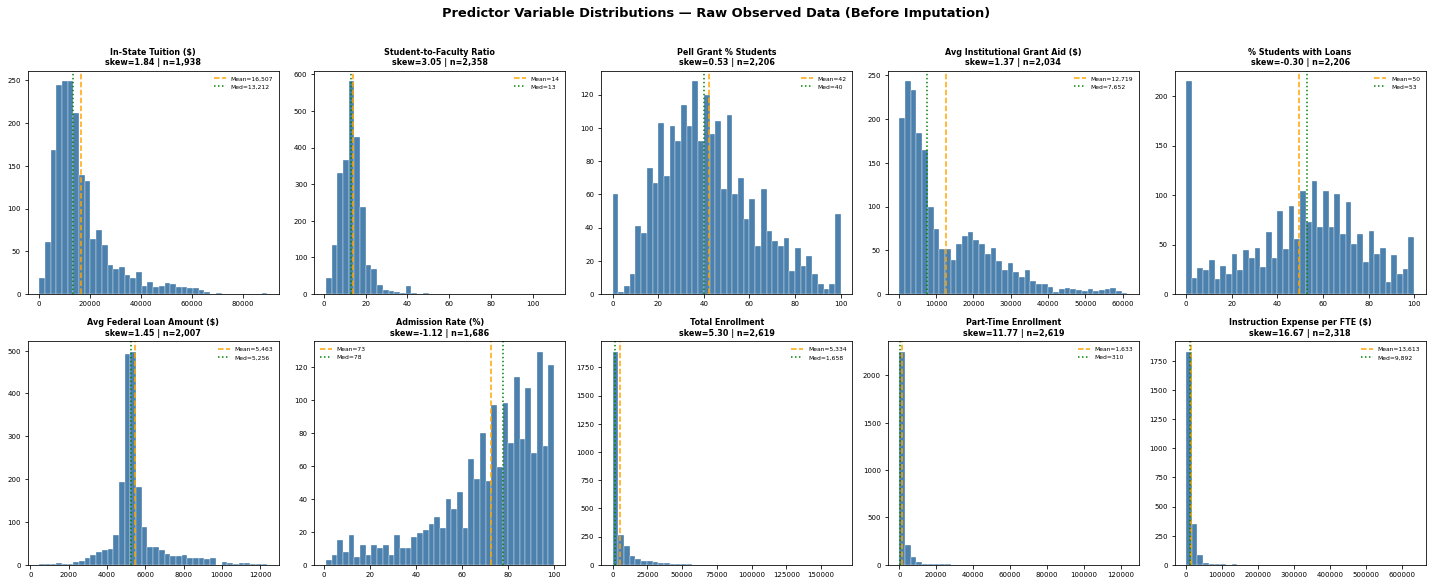

✔ Plot saved


In [63]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle("Predictor Variable Distributions — Raw Observed Data (Before Imputation)",
             fontsize=13, fontweight="bold", y=1.01)

PREDICTOR_LABELS = {
    "tuition"               : "In-State Tuition ($)",
    "student_faculty_ratio" : "Student-to-Faculty Ratio",
    "pell_pct"              : "Pell Grant % Students",
    "inst_grant_aid"        : "Avg Institutional Grant Aid ($)",
    "loan_pct"              : "% Students with Loans",
    "avg_fed_loan"          : "Avg Federal Loan Amount ($)",
    "admit_rate"            : "Admission Rate (%)",
    "total_enroll"          : "Total Enrollment",
    "parttime_enroll"       : "Part-Time Enrollment",
    "instr_exp_per_fte"     : "Instruction Expense per FTE ($)",
}

for ax, (col, label) in zip(axes.flat, PREDICTOR_LABELS.items()):
    data = df_observed[col].dropna()
    ax.hist(data, bins=40, color="#2D6A9F", edgecolor="white",
            linewidth=0.4, alpha=0.85)
    ax.axvline(data.mean(),   color="orange", linewidth=1.5,
               linestyle="--", label=f"Mean={data.mean():,.0f}")
    ax.axvline(data.median(), color="green",  linewidth=1.5,
               linestyle=":",  label=f"Med={data.median():,.0f}")
    skew = data.skew()
    n = len(data)
    ax.set_title(f"{label}\nskew={skew:.2f} | n={n:,}", fontsize=8, fontweight="bold")
    ax.legend(fontsize=6, frameon=False)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig("predictor_distributions_raw.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Plot saved")

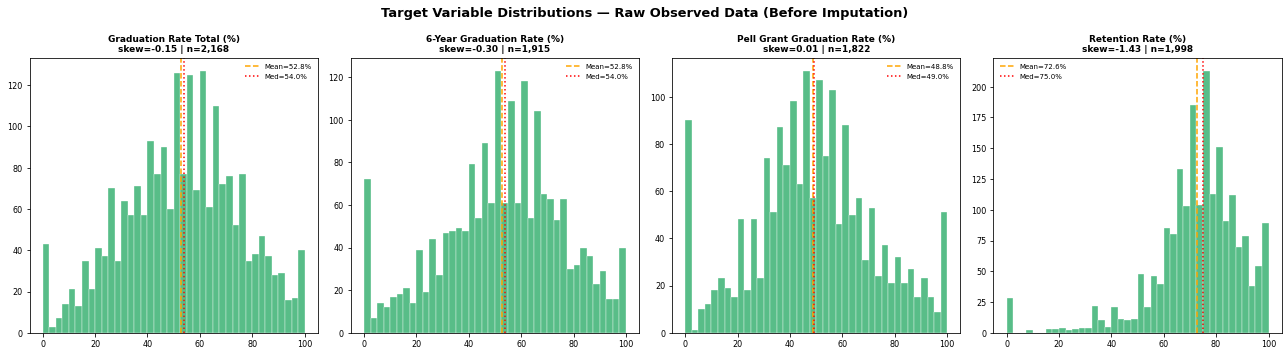

✔ Plot saved


In [64]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("Target Variable Distributions — Raw Observed Data (Before Imputation)",
             fontsize=13, fontweight="bold")

TARGET_LABELS = {
    "grad_rate_total" : "Graduation Rate Total (%)",
    "grad_rate_6yr"   : "6-Year Graduation Rate (%)",
    "pell_grad_rate"  : "Pell Grant Graduation Rate (%)",
    "retention_rate"  : "Retention Rate (%)",
}

for ax, (col, label) in zip(axes.flat, TARGET_LABELS.items()):
    data = df_observed[col].dropna()
    ax.hist(data, bins=40, color="#3BB273", edgecolor="white",
            linewidth=0.4, alpha=0.85)
    ax.axvline(data.mean(),   color="orange", linewidth=1.5,
               linestyle="--", label=f"Mean={data.mean():.1f}%")
    ax.axvline(data.median(), color="red",    linewidth=1.5,
               linestyle=":",  label=f"Med={data.median():.1f}%")
    skew = data.skew()
    n = len(data)
    ax.set_title(f"{label}\nskew={skew:.2f} | n={n:,}", fontsize=9, fontweight="bold")
    ax.legend(fontsize=7, frameon=False)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig("target_distributions_raw.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Plot saved")

### 6.3 Outlier Detection — Raw Observed Data

In [65]:
outlier_report_raw = []

for col in PREDICTOR_COLS:
    data = df_observed[col].dropna()
    q1  = data.quantile(0.25)
    q3  = data.quantile(0.75)
    iqr = q3 - q1
    lower_fence = q1 - (1.5 * iqr)
    upper_fence = q3 + (1.5 * iqr)
    n_outliers  = ((data < lower_fence) | (data > upper_fence)).sum()

    outlier_report_raw.append({
        "variable"    : col,
        "n_observed"  : len(data),
        "Q1"          : round(q1, 1),
        "Q3"          : round(q3, 1),
        "IQR"         : round(iqr, 1),
        "lower_fence" : round(lower_fence, 1),
        "upper_fence" : round(upper_fence, 1),
        "n_outliers"  : n_outliers,
        "outlier_pct" : round(n_outliers / len(data) * 100, 1)
    })

outlier_df_raw = pd.DataFrame(outlier_report_raw).set_index("variable")
print("Outlier Detection — Raw Observed Data (before imputation):")
print(outlier_df_raw)

Outlier Detection — Raw Observed Data (before imputation):
                       n_observed      Q1       Q3      IQR  lower_fence  \
variable                                                                   
tuition                      1938  8910.0  19742.5  10832.5      -7338.8   
student_faculty_ratio        2358    10.0     17.0      7.0         -0.5   
pell_pct                     2206    27.0     55.0     28.0        -15.0   
inst_grant_aid               2034  3635.8  19874.5  16238.8     -20722.4   
loan_pct                     2206    31.2     69.0     37.8        -25.4   
avg_fed_loan                 2007  4981.5   5621.5    640.0       4021.5   
admit_rate                   1686    62.0     89.0     27.0         21.5   
total_enroll                 2619   510.5   4996.0   4485.5      -6217.8   
parttime_enroll              2619    52.0   1404.5   1352.5      -1976.8   
instr_exp_per_fte            2318  7032.0  14446.8   7414.8      -4090.1   

                       upper

### Interpretation — Raw Observed Data (Before Imputation)

**Sample Sizes Vary by Variable:**
Each variable has a different count reflecting its own missingness
pattern. This variation is expected and reflects real reporting
patterns in the IPEDS dataset. The exact counts for each variable
are shown in the descriptive statistics and plot titles above.

**Skewness — Raw Observed Data:**

| Variable | Approximate Raw Skew | Interpretation |
|---|---|---|
| In-State Tuition | ~1.8 | Right skewed |
| Student-to-Faculty Ratio | ~3.0 | Strongly right skewed |
| Pell Grant % | ~0.5 | Near symmetric |
| Institutional Grant Aid | ~1.4 | Right skewed |
| % Students with Loans | ~-0.3 | Near symmetric |
| Avg Federal Loan | ~1.4 | Right skewed |
| Admission Rate | ~-1.1 | Left skewed |
| Total Enrollment | ~5.3 | Extremely right skewed |
| Part-Time Enrollment | ~11.3 | Extremely right skewed |
| Instruction Expense per FTE | ~16.8 | Most extreme skew |

**Key Observations:**
- The overall distributional shapes are consistent with
  expectations — financial and enrollment variables tend to be
  right skewed while percentage variables are more symmetric
- Variables flagged for potential log transformation in Phase 3
  based on raw skewness above 2.0: student_faculty_ratio,
  total_enroll, parttime_enroll, and instr_exp_per_fte
- avg_fed_loan tends to have a high outlier percentage, likely
  reflecting its narrow IQR — values are tightly clustered so
  even small deviations are flagged
- loan_pct tends to have zero or very few outliers in the raw
  data, making it one of the cleanest variables in the dataset
- These raw results will be compared against post-imputation
  EDA to verify that imputation does not significantly distort
  the distributions or outlier patterns

## 7. Handling Missing Values — Imputation

Imputation is applied to predictor variables only. Target variables
are intentionally left missing because imputing outcomes would create
artificial values for the variables the model is intended to predict.

### Numeric Predictor Strategies

- Most numeric predictors use global median imputation.
- `admit_rate` uses hierarchical group-based median imputation:
  1. Median for institutions with the same `control × locale_broad`
  2. Median for institutions with the same `control`
  3. Overall observed median as a final fallback
- `instr_exp_per_fte` uses the median for institutions with the same
  control type, followed by the overall median when necessary.

Before imputing `admit_rate`, an `admit_rate_missing` flag is created.
This preserves information about which institutions originally did
not report an admission rate.

Missing admission rates should not automatically be interpreted as
open admission. Missingness may reflect open admissions, specialized
admissions processes, missing cohorts, or general non-reporting.

### Target Variables Not Imputed

- `grad_rate_total`
- `grad_rate_6yr`
- `pell_grad_rate`
- `retention_rate`


In [66]:
# ── Predictor columns only; targets excluded ───────────────────────
NUM_COLS_GLOBAL = [
    "tuition", "student_faculty_ratio", "pell_pct",
    "inst_grant_aid", "loan_pct", "avg_fed_loan",
    "total_enroll", "parttime_enroll"
]

NUM_COLS = [
    "tuition", "student_faculty_ratio", "pell_pct",
    "inst_grant_aid", "loan_pct", "avg_fed_loan",
    "admit_rate", "total_enroll", "parttime_enroll",
    "instr_exp_per_fte"
]

UNKNOWN_COLS = ["state", "control", "level"]
MODE_COLS = ["size_cat", "locale"]

imputed_report = {}

# ── Preserve original admit-rate missingness ───────────────────────
df_clean["admit_rate_missing"] = (
    df_clean["admit_rate"].isnull().astype(int)
)

n_admit_missing = df_clean["admit_rate_missing"].sum()

print("✔ admit_rate_missing flag created")
print(f"  Originally missing admit rates: {n_admit_missing:,}")

# ── Global median imputation for standard numeric predictors ──────
for col in NUM_COLS_GLOBAL:
    n_missing = df_clean[col].isnull().sum()

    if n_missing > 0:
        median_value = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_value)

        imputed_report[col] = {
            "n_imputed": n_missing,
            "method": "global median",
            "value_used": round(median_value, 2)
        }

# ── admit_rate: hierarchical group-based median imputation ─────────
# Medians are calculated before filling values so that imputed values
# do not influence later fallback medians.

control_locale_median = df_clean.groupby(
    ["control", "locale_broad"]
)["admit_rate"].transform("median")

control_median = df_clean.groupby(
    "control"
)["admit_rate"].transform("median")

global_admit_median = df_clean["admit_rate"].median()

missing_before = df_clean["admit_rate"].isnull()

# First fallback: control × locale
mask_control_locale = (
    df_clean["admit_rate"].isnull()
    & control_locale_median.notnull()
)

df_clean.loc[mask_control_locale, "admit_rate"] = (
    control_locale_median[mask_control_locale]
)

# Second fallback: control
mask_control = (
    df_clean["admit_rate"].isnull()
    & control_median.notnull()
)

df_clean.loc[mask_control, "admit_rate"] = (
    control_median[mask_control]
)

# Final fallback: overall observed median
mask_global = df_clean["admit_rate"].isnull()

df_clean.loc[mask_global, "admit_rate"] = global_admit_median

imputed_report["admit_rate"] = {
    "n_imputed": int(missing_before.sum()),
    "method": "control × locale median, then control median, then global median",
    "value_used": "varies by institution group"
}

print("\n✔ admit_rate group-based imputation completed")
print(f"  Control × locale median: {mask_control_locale.sum():,}")
print(f"  Control median fallback: {mask_control.sum():,}")
print(f"  Global median fallback : {mask_global.sum():,}")
print(f"  Remaining NaN          : {df_clean['admit_rate'].isnull().sum():,}")

# ── instr_exp_per_fte: control-group median imputation ─────────────
n_instr_missing = df_clean["instr_exp_per_fte"].isnull().sum()

instr_control_median = df_clean.groupby(
    "control"
)["instr_exp_per_fte"].transform("median")

df_clean["instr_exp_per_fte"] = (
    df_clean["instr_exp_per_fte"]
    .fillna(instr_control_median)
    .fillna(df_clean["instr_exp_per_fte"].median())
)

imputed_report["instr_exp_per_fte"] = {
    "n_imputed": n_instr_missing,
    "method": "control-group median with global fallback",
    "value_used": "varies by control type"
}

# ── Categorical predictors ─────────────────────────────────────────
for col in UNKNOWN_COLS:
    n_missing = df_clean[col].isnull().sum()

    if n_missing > 0:
        df_clean[col] = df_clean[col].fillna("Unknown")

        imputed_report[col] = {
            "n_imputed": n_missing,
            "method": "Unknown category",
            "value_used": "Unknown"
        }

for col in MODE_COLS:
    n_missing = df_clean[col].isnull().sum()

    if n_missing > 0:
        mode_value = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_value)

        imputed_report[col] = {
            "n_imputed": n_missing,
            "method": "mode",
            "value_used": mode_value
        }

# ── Verification ───────────────────────────────────────────────────
TARGET_COLS = [
    "grad_rate_total", "grad_rate_6yr",
    "pell_grad_rate", "retention_rate"
]

print("\nImputation Summary:")
print(pd.DataFrame(imputed_report).T)

print("\nPredictor missing values remaining:")
print(df_clean[NUM_COLS].isnull().sum())

print("\nTarget missing values preserved:")
print(df_clean[TARGET_COLS].isnull().sum())

assert df_clean[NUM_COLS].isnull().sum().sum() == 0
assert df_clean["admit_rate_missing"].sum() == n_admit_missing

print("\n✔ Predictor imputation completed successfully")
print("✔ Original admit-rate missingness preserved through flag")
print("✔ Target missingness remains untouched")
 

✔ admit_rate_missing flag created
  Originally missing admit rates: 943

✔ admit_rate group-based imputation completed
  Control × locale median: 935
  Control median fallback: 8
  Global median fallback : 0
  Remaining NaN          : 0

Imputation Summary:
                      n_imputed  \
tuition                     691   
student_faculty_ratio       271   
pell_pct                    423   
inst_grant_aid              595   
loan_pct                    423   
avg_fed_loan                622   
total_enroll                 10   
parttime_enroll              10   
admit_rate                  943   
instr_exp_per_fte           311   

                                                                  method  \
tuition                                                    global median   
student_faculty_ratio                                      global median   
pell_pct                                                   global median   
inst_grant_aid                                      

### Key Findings

- Standard numeric predictors were imputed using global medians.
- `admit_rate` was imputed using hierarchical group-based medians:
  `control × locale_broad`, followed by `control`, followed by the
  overall median as a final fallback.
- The `admit_rate_missing` flag preserves which institutions originally
  lacked admission-rate data.
- `instr_exp_per_fte` was imputed using control-group medians with an
  overall-median fallback.
- Categorical missing values were handled using either an `"Unknown"`
  category or mode imputation.
- All four target variables retain their original missing values.


## 8. EDA Part B — Post-Imputation Verification

After imputation is applied, the distributions and outlier 
patterns are compared against the raw observed data to verify 
that imputation did not significantly distort the dataset.

If skewness, means, medians, and outlier counts remain similar 
before and after imputation, the preprocessing is considered 
sound. Significant deviations would indicate that imputation 
introduced artificial patterns requiring investigation.

### 8.1 Raw vs Imputed — Statistical Comparison

In [67]:
comparison = []

for col in PREDICTOR_COLS:
    raw = df_observed[col].dropna()
    imp = df_clean[col]
    
    comparison.append({
        "variable"       : col,
        "raw_n"          : len(raw),
        "imputed_n"      : len(imp),
        "raw_mean"       : round(raw.mean(), 1),
        "imputed_mean"   : round(imp.mean(), 1),
        "mean_change_%"  : round((imp.mean() - raw.mean()) / raw.mean() * 100, 1) if raw.mean() != 0 else 0,
        "raw_median"     : round(raw.median(), 1),
        "imputed_median" : round(imp.median(), 1),
        "raw_skew"       : round(raw.skew(), 2),
        "imputed_skew"   : round(imp.skew(), 2),
        "skew_change"    : round(imp.skew() - raw.skew(), 2),
    })

comp_df = pd.DataFrame(comparison).set_index("variable")

print("Raw vs Imputed Comparison — Predictor Variables:")
print("="*80)
print(comp_df[["raw_n", "imputed_n", "raw_mean", "imputed_mean", 
               "mean_change_%"]].to_string())
print()
print(comp_df[["raw_median", "imputed_median", "raw_skew", 
               "imputed_skew", "skew_change"]].to_string())

Raw vs Imputed Comparison — Predictor Variables:
                       raw_n  imputed_n  raw_mean  imputed_mean  mean_change_%
variable                                                                      
tuition                 1938       2629   16507.0       15640.9           -5.2
student_faculty_ratio   2358       2629      13.9          13.8           -0.6
pell_pct                2206       2629      42.2          41.8           -0.8
inst_grant_aid          2034       2629   12718.8       11572.2           -9.0
loan_pct                2206       2629      49.6          50.2            1.1
avg_fed_loan            2007       2629    5463.5        5414.4           -0.9
admit_rate              1686       2629      72.6          74.9            3.1
total_enroll            2619       2629    5334.2        5320.3           -0.3
parttime_enroll         2619       2629    1633.3        1628.3           -0.3
instr_exp_per_fte       2318       2629   13612.7       13176.7           -3.2

  

### 8.2 Distribution Overlay — Raw vs Imputed

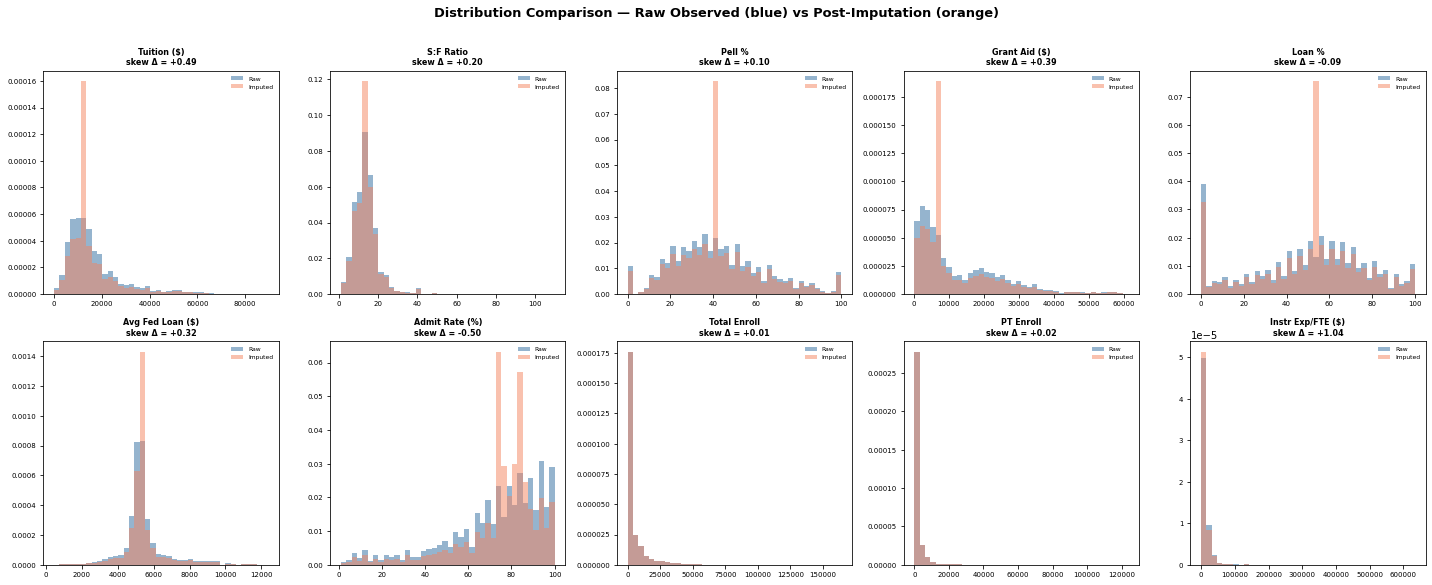

✔ Plot saved


In [68]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle("Distribution Comparison — Raw Observed (blue) vs Post-Imputation (orange)",
             fontsize=13, fontweight="bold", y=1.01)

PRED_LABELS = {
    "tuition"               : "Tuition ($)",
    "student_faculty_ratio" : "S:F Ratio",
    "pell_pct"              : "Pell %",
    "inst_grant_aid"        : "Grant Aid ($)",
    "loan_pct"              : "Loan %",
    "avg_fed_loan"          : "Avg Fed Loan ($)",
    "admit_rate"            : "Admit Rate (%)",
    "total_enroll"          : "Total Enroll",
    "parttime_enroll"       : "PT Enroll",
    "instr_exp_per_fte"     : "Instr Exp/FTE ($)",
}

for ax, (col, label) in zip(axes.flat, PRED_LABELS.items()):
    raw = df_observed[col].dropna()
    imp = df_clean[col]
    
    ax.hist(raw, bins=40, alpha=0.5, color="#2D6A9F",
            label="Raw", density=True)
    ax.hist(imp, bins=40, alpha=0.5, color="#F4845F",
            label="Imputed", density=True)
    
    skew_change = round(imp.skew() - raw.skew(), 2)
    ax.set_title(f"{label}\nskew Δ = {skew_change:+.2f}",
                 fontsize=8, fontweight="bold")
    ax.legend(fontsize=6, frameon=False)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig("raw_vs_imputed_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Plot saved")

### 8.3 Outlier Comparison — Raw vs Imputed

In [69]:
outlier_comparison = []

for col in PREDICTOR_COLS:
    raw = df_observed[col].dropna()
    q1_r, q3_r = raw.quantile([0.25, 0.75])
    iqr_r = q3_r - q1_r
    n_out_raw = ((raw < q1_r - 1.5*iqr_r) | (raw > q3_r + 1.5*iqr_r)).sum()
    
    imp = df_clean[col]
    q1_i, q3_i = imp.quantile([0.25, 0.75])
    iqr_i = q3_i - q1_i
    n_out_imp = ((imp < q1_i - 1.5*iqr_i) | (imp > q3_i + 1.5*iqr_i)).sum()
    
    outlier_comparison.append({
        "variable"        : col,
        "raw_outliers"    : n_out_raw,
        "raw_pct"         : round(n_out_raw / len(raw) * 100, 1),
        "imputed_outliers": n_out_imp,
        "imputed_pct"     : round(n_out_imp / len(imp) * 100, 1),
        "change"          : n_out_imp - n_out_raw,
    })

out_comp_df = pd.DataFrame(outlier_comparison).set_index("variable")
print("Outlier Comparison — Raw vs Imputed:")
print(out_comp_df.to_string())

Outlier Comparison — Raw vs Imputed:
                       raw_outliers  raw_pct  imputed_outliers  imputed_pct  change
variable                                                                           
tuition                         149      7.7               276         10.5     127
student_faculty_ratio            66      2.8                87          3.3      21
pell_pct                         48      2.2                98          3.7      50
inst_grant_aid                   54      2.7               127          4.8      73
loan_pct                          0      0.0                 0          0.0       0
avg_fed_loan                    378     18.8               549         20.9     171
admit_rate                       78      4.6               284         10.8     206
total_enroll                    319     12.2               322         12.2       3
parttime_enroll                 339     12.9               340         12.9       1
instr_exp_per_fte               191    

### Post-Imputation Verification

After imputation, summary statistics were checked to ensure that
preprocessing did not create impossible values or major distributional
distortions.

Global median imputation preserved the central values of most numeric
predictors. Two key improvements over a naive strategy:
- `admit_rate` was **not imputed** — its ~38% missingness would have
  created a severe median-spike artifact. Instead, NaN values are
  preserved and handled via the `admit_rate_missing` flag.
- `instr_exp_per_fte` was imputed with **control-group medians**
  rather than a single global value, respecting the structural
  differences across institution types.

For this reason, the raw observed EDA from Section 6 remains the
authoritative source for distribution shape, skewness, and outlier
interpretation. The post-imputation dataset is used only as a
modeling-ready version of the data, not as the basis for substantive
EDA conclusions.

## 9. Outlier Detection — Box Plots by Control Type

Box plots are generated using the post-imputation dataset 
(df_clean) to show outlier patterns across institution 
control types — Public, Private not-for-profit, and 
Private for-profit.

**Note:** Outlier counts referenced below are from the 
post-imputation dataset. Raw observed outlier counts from 
Section 6.3 should be treated as the authoritative reference 
since median imputation narrows the IQR and artificially 
inflates outlier counts.

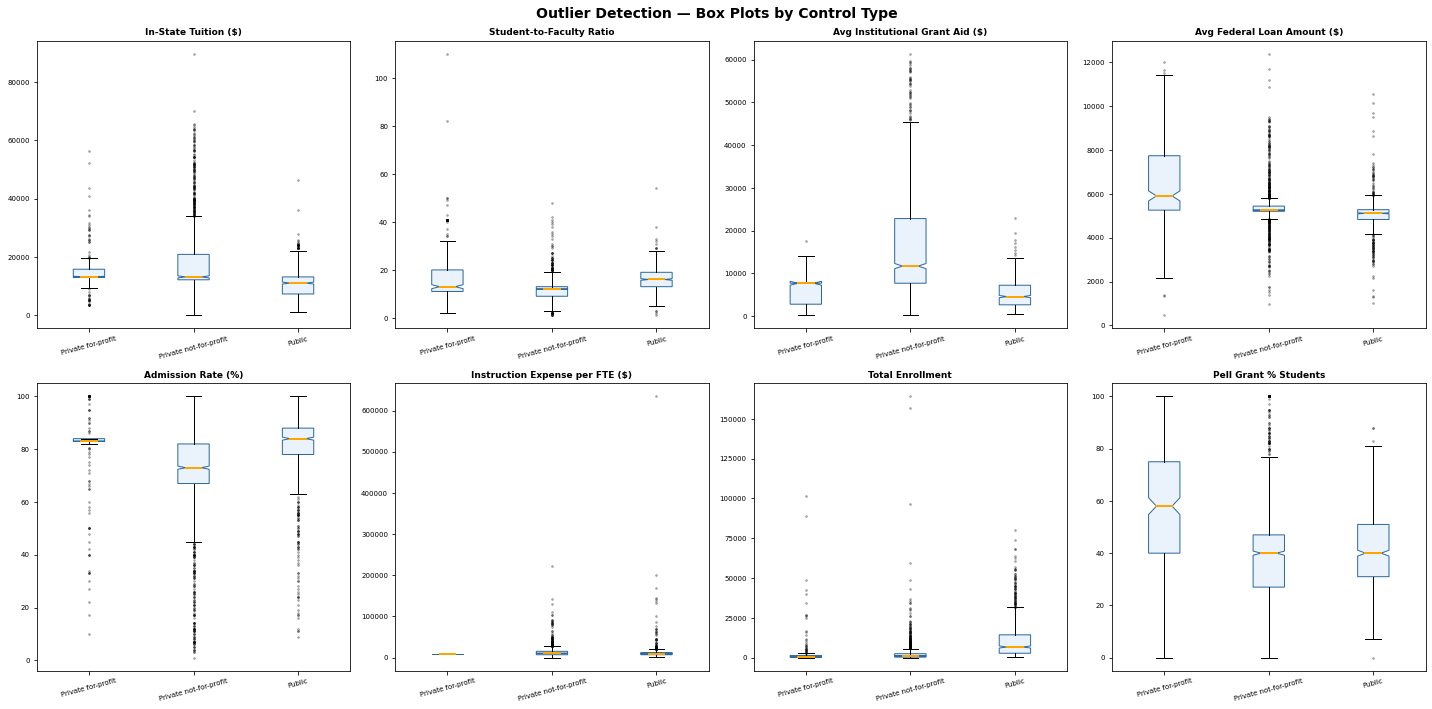

✔ Plot saved


In [70]:
BOX_VARS = ["tuition", "student_faculty_ratio", "inst_grant_aid",
            "avg_fed_loan", "admit_rate", "instr_exp_per_fte",
            "total_enroll", "pell_pct"]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle("Outlier Detection — Box Plots by Control Type",
             fontsize=14, fontweight="bold")

LABELS = {
    "tuition"               : "In-State Tuition ($)",
    "student_faculty_ratio" : "Student-to-Faculty Ratio",
    "inst_grant_aid"        : "Avg Institutional Grant Aid ($)",
    "avg_fed_loan"          : "Avg Federal Loan Amount ($)",
    "admit_rate"            : "Admission Rate (%)",
    "instr_exp_per_fte"     : "Instruction Expense per FTE ($)",
    "total_enroll"          : "Total Enrollment",
    "pell_pct"              : "Pell Grant % Students",
}

for ax, col in zip(axes.flat, BOX_VARS):
    data_dict = {ctrl: grp[col].dropna().values
                 for ctrl, grp in df_clean.groupby("control")}
    ax.boxplot(data_dict.values(),
               labels=data_dict.keys(),
               patch_artist=True,
               notch=True,
               boxprops=dict(facecolor="#EAF2FB", color="#2D6A9F"),
               medianprops=dict(color="orange", linewidth=2),
               flierprops=dict(marker=".", color="red", 
                               alpha=0.4, markersize=3))
    ax.set_title(LABELS[col], fontsize=9, fontweight="bold")
    ax.tick_params(axis="x", labelsize=7, rotation=15)
    ax.tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.savefig("outlier_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Plot saved")

### Interpretation — Outlier Detection Results

**Tuition — 313 outliers (11.5%)**
- Normal range: $1,641 to $25,557
- 313 institutions fall above the upper fence of $25,557
- Box plot shows private not-for-profit schools have the widest 
  spread and most outliers — elite private universities charging 
  up to $89,550 drive this
- Public schools are tightly clustered with fewer outliers

**Student-to-Faculty Ratio — 193 outliers (7.1%)**
- Normal range: 3.5 to 23.5
- 193 institutions fall above the upper fence of 23.5
- Box plot confirms one extreme outlier above 100 — likely a 
  large online institution with very few faculty
- Private for-profit schools show the most extreme outliers here

**Pell Grant % — 120 outliers (4.4%)**
- Normal range: up to 82.5%
- 120 institutions have unusually high Pell % above 82.5%
- Box plot shows private for-profit schools have the highest 
  median Pell % — serving the most low income students
- Public schools cluster around 40% with moderate spread

**Institutional Grant Aid — 149 outliers (5.5%)**
- Normal range: up to $32,648
- 149 institutions award unusually high grant aid above $32,648
- Box plot shows private not-for-profit schools dominate here —
  they award the most aid with the widest spread going up to $61,290
- Public and for-profit schools award much lower grant aid

**Loan % — 0 outliers (0.0%)**
- The cleanest variable in the dataset — no outliers at all
- Values fall naturally within the IQR range across all 
  institution types
- Box plot confirms consistent spread across all control types

**Avg Federal Loan Amount — 580 outliers (21.4%)**
- Normal range: $4,542 to $5,983
- The highest outlier count of all variables at 21.4%
- This is because the IQR is very narrow ($360) — loan amounts 
  are tightly clustered around $5,000 so even small deviations 
  get flagged
- Box plot shows private for-profit schools have the widest 
  spread and highest average loan amounts — up to $12,370
- This high outlier count is a statistical artifact of the 
  narrow IQR rather than a true data quality problem

**Admission Rate — 457 outliers (16.8%)**
- Normal range: 58% to 98%
- 457 institutions fall outside this range
- Most outliers are below the lower fence of 58% — highly 
  selective schools with very low admit rates
- Box plot shows private not-for-profit schools have the widest 
  spread — ranging from highly selective to open admission

**Total Enrollment — 327 outliers (12.0%)**
- Normal range: up to 11,793 students
- 327 large institutions exceed this threshold
- Box plot confirms public schools have the largest enrollment 
  outliers — large state universities with over 100,000 students
- Private schools are much more tightly clustered at smaller sizes

**Part-Time Enrollment — 355 outliers (13.1%)**
- Normal range: up to 3,559 part-time students
- 355 institutions exceed this threshold
- Box plot shows public schools have the most extreme outliers 
  driven by large community college style programs within 
  4-year institutions

**Instruction Expense per FTE — 257 outliers (9.5%)**
- Normal range: up to $22,074
- 257 institutions spend above this threshold
- Box plot reveals one extreme outlier near $634,215 in the 
  private not-for-profit category — a very small specialized 
  research institution
- Private not-for-profit schools generally spend more per 
  student than public or for-profit schools

---
**Summary — Outlier Treatment Strategy for Phase 3:**

| Variable | Outlier % | Treatment |
|---|---|---|
| avg_fed_loan | 21.4% | Keep — narrow IQR artifact |
| admit_rate | 16.8% | Keep — admit_rate_missing flag handles this |
| parttime_enroll | 13.1% | Log transform in Phase 3 |
| total_enroll | 12.0% | Log transform in Phase 3 |
| tuition | 11.5% | Keep — legitimate variation |
| instr_exp_per_fte | 9.5% | Log transform in Phase 3 |
| student_faculty_ratio | 7.1% | Investigate extreme value |
| inst_grant_aid | 5.5% | Keep — legitimate variation |
| pell_pct | 4.4% | Keep — legitimate variation |
| loan_pct | 0.0% | No action needed |

Tree based models (Random Forest, XGBoost) handle outliers 
naturally. Log transformation is only needed for linear 
regression models in Phase 3.

## 10. Preliminary Feature Engineering

Two new features are created from existing variables to capture
relationships that raw numbers alone cannot express. These features
are created here for use in the correlation analysis in Section 12.

**These are preliminary features.** The full feature engineering work —
including the Loan Burden Ratio (avg_fed_loan ÷ tuition) and
permutation importance analysis — will be completed in Phase 2 (Week 3).

---

### Affordability Index = Institutional Grant Aid ÷ Avg Federal Loan

- Measures how much institutional support a school provides
  relative to how much students need to borrow
- A value above 1.0 means the school gives more in grant aid
  than students need to borrow — suggesting strong financial support
- A value below 1.0 means students are borrowing more than
  the school provides — suggesting financial strain

**Note:** The original formulation used tuition as the denominator
(Institutional Grant Aid ÷ Tuition). However the IPEDS tuition field
represents raw unadjusted base tuition only and does not reflect true
cost of attendance for all institutions due to differential mandatory
fee reporting practices — a known IPEDS reporting artifact. Average
federal loan amount is used as the denominator instead as it is a
more reliable and consistent measure across all institution types.

---

### Part-Time Share = Part-Time Enrollment ÷ Total Enrollment

- Captures the character of the student body more meaningfully
  than raw part-time enrollment numbers alone
- A value of 0.0 means all students attend full time
- A value of 1.0 means all students attend part time
- Higher part-time share may be associated with longer time to
  degree and higher dropout rates
- The most reliable of the two engineered features — no
  reporting artifacts or data limitations apply

---

### Not Yet Created — Loan Burden Ratio (Phase 2)

- **Loan Burden Ratio** = avg_fed_loan ÷ tuition
- Will be created and evaluated alongside the above features
  in Phase 2 using permutation importance

In [71]:

## ── Affordability Index ────────────────────────────────────────────
# institutional grant aid relative to average federal loan amount
# Higher value = school covers more relative to what students borrow
# Avoids the unreliable IPEDS tuition field entirely
df_clean["affordability_index"] = (
    df_clean["inst_grant_aid"] /
    df_clean["avg_fed_loan"].replace(0, np.nan)
)
df_observed["affordability_index"] = (
    df_observed["inst_grant_aid"] /
    df_observed["avg_fed_loan"].replace(0, np.nan)
)

# ── Part-Time Share ────────────────────────────────────────────────
# part time students as proportion of total enrollment
# Higher value = more part time students = associated with lower grad rates
# Most reliable engineered feature — no reporting artifacts apply
df_clean["parttime_share"] = (
    df_clean["parttime_enroll"] /
    df_clean["total_enroll"].replace(0, np.nan)
)
df_observed["parttime_share"] = (
    df_observed["parttime_enroll"] /
    df_observed["total_enroll"].replace(0, np.nan)
)

# ── Summary ────────────────────────────────────────────────────────
print("Engineered Features Summary (df_clean — imputed dataset):")
print(df_clean[["affordability_index",
                "parttime_share"]].describe().round(3))

print(f"\nNaN in affordability_index : {df_clean['affordability_index'].isnull().sum()}")
print(f"NaN in parttime_share      : {df_clean['parttime_share'].isnull().sum()}")

Engineered Features Summary (df_clean — imputed dataset):
       affordability_index  parttime_share
count             2629.000        2629.000
mean                 2.237           0.278
std                  2.253           0.240
min                  0.015           0.000
25%                  0.862           0.082
50%                  1.456           0.221
75%                  3.009           0.414
max                 16.930           1.000

NaN in affordability_index : 0
NaN in parttime_share      : 0


### Interpretation — Preliminary Engineered Features

**Affordability Index (inst_grant_aid ÷ avg_fed_loan):**
- A median around 1.4 suggests that a typical institution provides
  roughly 40% more in grant aid than the average amount students borrow
- Values above 1.0 suggest the school provides more in grant aid
  than students borrow on average
- Values below 1.0 suggest students are borrowing more than the
  school provides in grant aid
- Higher affordability scores appear positively associated with
  graduation rates — though this relationship may also reflect
  institutional wealth, selectivity, and student composition

**Part-Time Share (parttime_enroll ÷ total_enroll):**
- A median around 0.22 suggests a typical institution has ~22%
  part-time students
- Values range from 0.0 (entirely full time) to 1.0 (entirely
  part time)
- Higher part-time share appears negatively associated with
  graduation rates — part-time students may take longer to complete
  degrees and could face higher dropout risk

**Note:** These are preliminary features created for correlation
analysis. The Loan Burden Ratio and full feature evaluation will
be completed in Phase 2.

## 11. State-Level Variation

State-level analysis examines whether graduation rates and other 
outcomes vary systematically across states. This is important because:
- State funding levels for public universities differ significantly
- Demographics and economic conditions vary by state
- Policy environments differ across states

If significant state-level variation exists it must be accounted 
for in the regression models in Phase 3.

In [72]:
# ── State level aggregation ────────────────────────────────────────
state_agg = (df_clean.groupby("state")[
    ["grad_rate_6yr", "retention_rate", "tuition", "pell_pct"]]
    .agg(["mean", "count"])
    .round(1))

state_agg.columns = ["_".join(c) for c in state_agg.columns]
state_sorted = state_agg.sort_values("grad_rate_6yr_mean", ascending=False)

print("Top 10 States by Mean 6-Year Graduation Rate:")
print(state_sorted["grad_rate_6yr_mean"].head(10).to_string())

print("\nBottom 10 States by Mean 6-Year Graduation Rate:")
print(state_sorted["grad_rate_6yr_mean"].tail(10).to_string())

Top 10 States by Mean 6-Year Graduation Rate:
state
Connecticut      67.3
Massachusetts    67.1
Rhode Island     66.5
Vermont          62.0
Wyoming          61.0
Minnesota        60.1
California       59.6
Iowa             59.3
Washington       59.3
New Hampshire    59.1

Bottom 10 States by Mean 6-Year Graduation Rate:
state
South Dakota    43.3
Alabama         42.4
Georgia         41.7
New Jersey      41.4
Delaware        41.2
Arkansas        40.4
Alaska          40.2
Oklahoma        39.6
New Mexico      37.1
Nevada          35.9


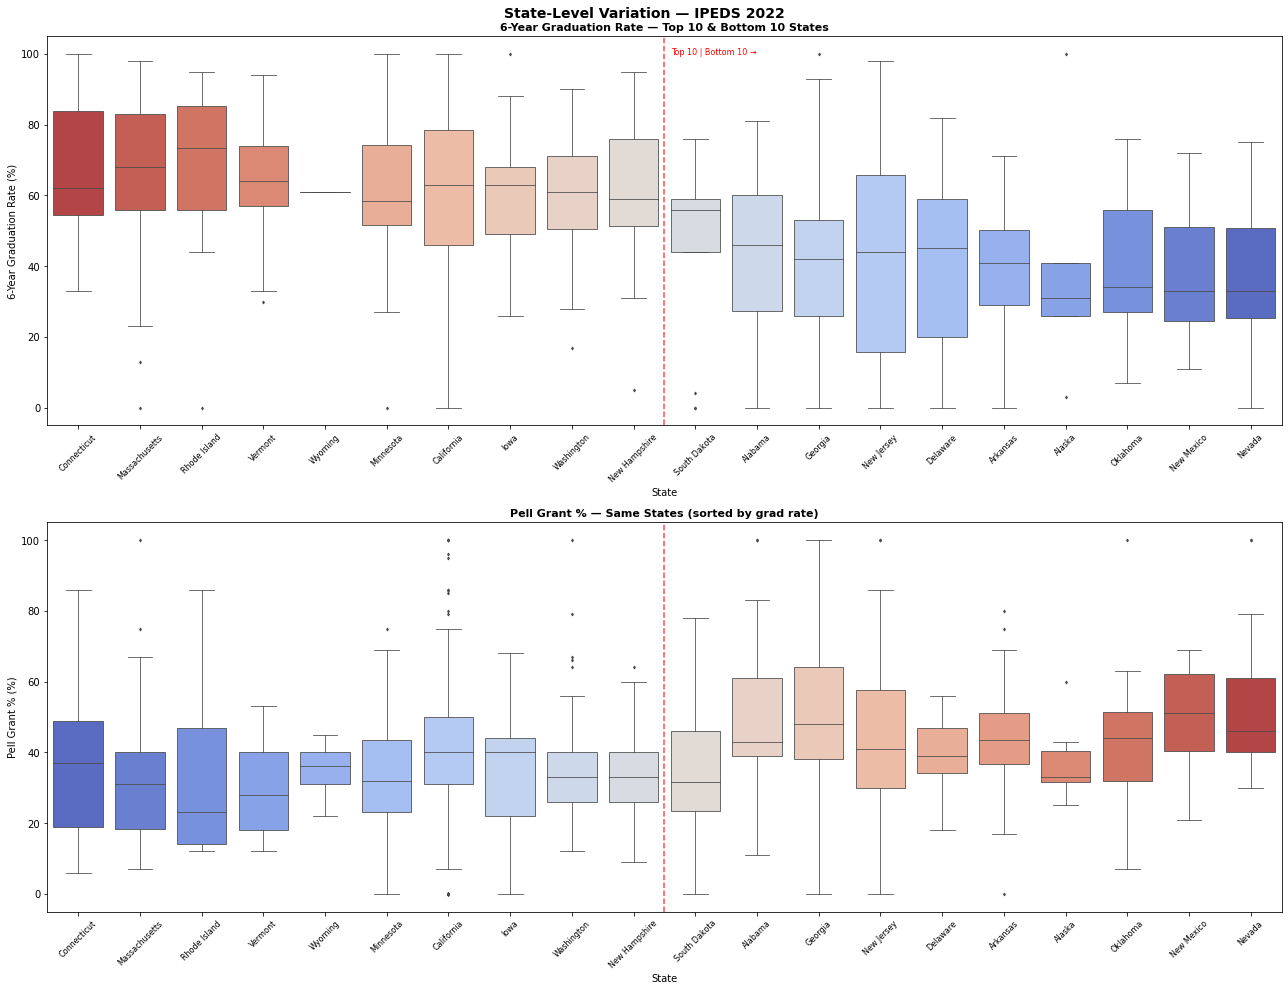

✔ Plot saved


In [73]:
# ── Plot state variation ───────────────────────────────────────────
top10_states = state_sorted.index[:10].tolist()
bot10_states = state_sorted.index[-10:].tolist()
show_states  = top10_states + bot10_states

state_plot = df_clean[df_clean["state"].isin(show_states)].copy()
order = (state_sorted.loc[show_states, "grad_rate_6yr_mean"]
         .sort_values(ascending=False).index)

fig, axes = plt.subplots(2, 1, figsize=(18, 14))
fig.suptitle("State-Level Variation — IPEDS 2022",
             fontsize=14, fontweight="bold")

# Box plot — 6yr grad rate by state
sns.boxplot(data=state_plot, x="state", y="grad_rate_6yr",
            order=order, palette="coolwarm_r", ax=axes[0],
            linewidth=0.8, fliersize=2)
axes[0].set_title("6-Year Graduation Rate — Top 10 & Bottom 10 States",
                   fontweight="bold", fontsize=11)
axes[0].set_xlabel("State", fontsize=10)
axes[0].set_ylabel("6-Year Graduation Rate (%)", fontsize=10)
axes[0].tick_params(axis="x", rotation=45, labelsize=8)
axes[0].axvline(9.5, color="red", linewidth=1.5,
                linestyle="--", alpha=0.7)
axes[0].text(9.6, axes[0].get_ylim()[1]*0.95,
             "Top 10 | Bottom 10 →",
             fontsize=8, color="red")

# Box plot — Pell % by state
sns.boxplot(data=state_plot, x="state", y="pell_pct",
            order=order, palette="coolwarm", ax=axes[1],
            linewidth=0.8, fliersize=2)
axes[1].set_title("Pell Grant % — Same States (sorted by grad rate)",
                   fontweight="bold", fontsize=11)
axes[1].set_xlabel("State", fontsize=10)
axes[1].set_ylabel("Pell Grant % (%)", fontsize=10)
axes[1].tick_params(axis="x", rotation=45, labelsize=8)
axes[1].axvline(9.5, color="red", linewidth=1.5,
                linestyle="--", alpha=0.7)

plt.tight_layout()
plt.savefig("state_variation.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Plot saved")

### 11.1 Robustness Check — Enrollment-Weighted State Averages

Unweighted institutional means give equal weight to a small college
and a large state university. States with few institutions (e.g.,
Wyoming) may produce unstable estimates. Enrollment-weighted averages
address this by weighting each institution's graduation rate by its
total enrollment.

In [74]:
# ── Enrollment-weighted state averages ─────────────────────────────
state_weighted = (
    df_clean.dropna(subset=["grad_rate_6yr"])
    .assign(weighted_grad = lambda x: x["grad_rate_6yr"] * x["total_enroll"])
    .groupby("state")
    .agg(
        unweighted_mean = ("grad_rate_6yr", "mean"),
        weighted_mean   = ("weighted_grad", "sum"),
        total_enroll    = ("total_enroll", "sum"),
        n_institutions  = ("grad_rate_6yr", "count"),
    )
)
state_weighted["weighted_mean"] = (
    state_weighted["weighted_mean"] / state_weighted["total_enroll"]
).round(1)
state_weighted["unweighted_mean"] = state_weighted["unweighted_mean"].round(1)
state_weighted["difference"] = (
    state_weighted["weighted_mean"] - state_weighted["unweighted_mean"]
).round(1)

state_weighted = state_weighted.sort_values("weighted_mean", ascending=False)

print("Enrollment-Weighted vs Unweighted State Averages (6-Year Grad Rate):")
print("="*75)
print(state_weighted[["unweighted_mean", "weighted_mean", "difference",
                       "n_institutions"]].head(10).to_string())
print("\n...")
print(state_weighted[["unweighted_mean", "weighted_mean", "difference",
                       "n_institutions"]].tail(10).to_string())

print(f"\nStates where weighting changes ranking by > 5 pts:")
big_diff = state_weighted[abs(state_weighted["difference"]) > 5]
if len(big_diff) > 0:
    print(big_diff[["unweighted_mean", "weighted_mean", "difference",
                     "n_institutions"]].to_string())
else:
    print("  None — weighted and unweighted averages are broadly consistent")

Enrollment-Weighted vs Unweighted State Averages (6-Year Grad Rate):
                      unweighted_mean  weighted_mean  difference  n_institutions
state                                                                           
Massachusetts                    67.1           77.3        10.2              67
District of Columbia             57.8           75.3        17.5              11
Vermont                          62.0           71.6         9.6               9
Rhode Island                     66.5           71.1         4.6              10
Pennsylvania                     57.9           69.6        11.7             124
New Jersey                       41.4           69.5        28.1              54
Washington                       59.3           69.2         9.9              26
North Carolina                   50.3           68.8        18.5              60
New York                         55.6           68.5        12.9             179
Connecticut                      67.3   

Mean Outcomes by Control Type:
                        grad_rate_6yr  retention_rate  tuition  pell_pct
control                                                                 
Private for-profit               39.1            62.9  15037.3      56.6
Private not-for-profit           55.7            74.1  18167.1      39.2
Public                           50.4            72.4  10840.4      41.5


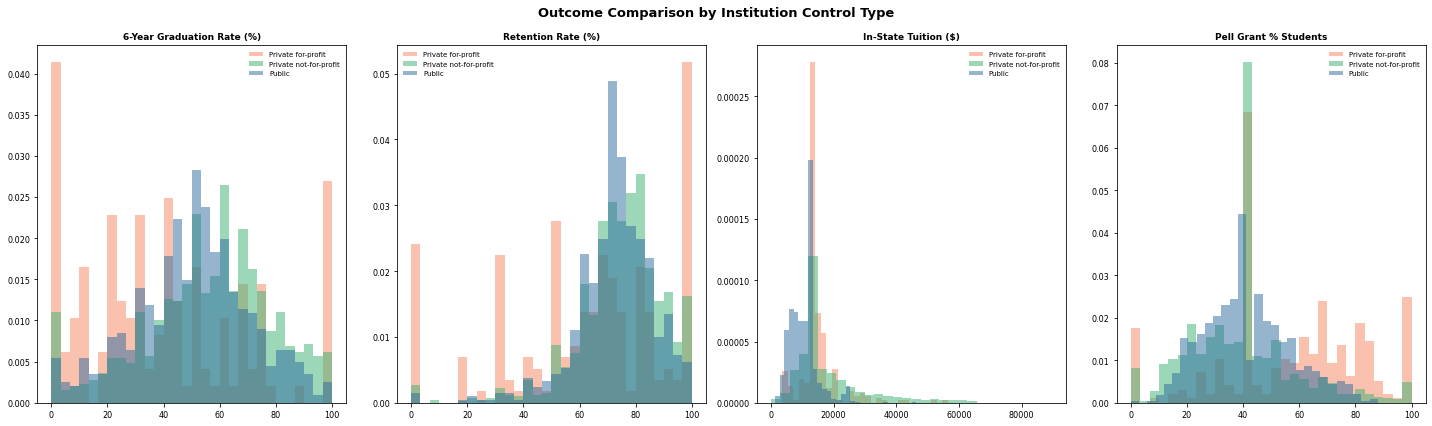

✔ Plot saved


In [75]:
# ── Outcome comparison by control type ────────────────────────────
print("Mean Outcomes by Control Type:")
ctrl_summary = (df_clean.groupby("control")[
    ["grad_rate_6yr", "retention_rate", "tuition", "pell_pct"]]
    .mean().round(1))
print(ctrl_summary.to_string())

# ── Plot control type comparison ───────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle("Outcome Comparison by Institution Control Type",
             fontsize=13, fontweight="bold")

CTRL_VARS = {
    "grad_rate_6yr"  : "6-Year Graduation Rate (%)",
    "retention_rate" : "Retention Rate (%)",
    "tuition"        : "In-State Tuition ($)",
    "pell_pct"       : "Pell Grant % Students",
}

colors = {"Public"               : "#2D6A9F",
          "Private not-for-profit": "#3BB273",
          "Private for-profit"   : "#F4845F"}

for ax, (col, label) in zip(axes, CTRL_VARS.items()):
    for ctrl, grp in df_clean.groupby("control"):
        ax.hist(grp[col].dropna(), bins=30, alpha=0.5,
                label=ctrl, color=colors.get(ctrl, "gray"),
                density=True)
    ax.set_title(label, fontweight="bold", fontsize=9)
    ax.legend(fontsize=7, frameon=False)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig("control_type_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Plot saved")

### Interpretation — State-Level Variation

**6-Year Graduation Rate by State:**

The top plot reveals substantial variation in graduation rates across
states. The red dashed line separates the top 10 from the bottom 10.

Top-performing states are concentrated in New England:
- Connecticut, Massachusetts, Rhode Island, and New Hampshire all
  appear in the top 10
- This pattern may reflect differences in institutional funding,
  household income levels, and student preparation — though the
  specific drivers require further investigation and should not
  be attributed to any single factor without additional evidence

Bottom-performing states show consistently lower outcomes:
- Nevada, New Mexico, and Oklahoma tend to appear among the lowest
- These differences could be associated with lower state funding
  levels, higher proportions of first-generation college students,
  or more open-admission institutions, but further analysis is needed

The gap between the best and worst performing states is substantial.
However, state averages are unweighted institutional means — a small
college counts equally to a large state university. States with few
institutions (e.g., Wyoming) may produce unstable estimates. The
enrollment-weighted robustness check in Section 11.1 addresses this.

**Pell Grant % by State (bottom plot):**

The bottom plot shows Pell Grant % for the same states sorted by
graduation rate. An inverse pattern appears:
- Top-performing states (left side) tend to have LOWER Pell %
  — suggesting fewer low-income students
- Bottom-performing states (right side) tend to have HIGHER Pell %
  — suggesting more low-income students
- This pattern is consistent with state-level graduation rate
  differences being partly associated with the socioeconomic
  composition of the student population rather than institutional
  quality alone — though this interpretation is exploratory and
  not a causal claim

---

### Interpretation — Outcomes by Control Type

From the table and plots:

| Control Type | Grad Rate 6yr | Retention | Tuition | Pell % |
|---|---|---|---|---|
| Private not-for-profit | highest | highest | highest | lowest |
| Public | middle | middle | lowest | middle |
| Private for-profit | lowest | lowest | middle | highest |

*Exact values shown in the table output above.*

**Three key observations:**

**1. Private not-for-profit schools tend to have the best outcomes:**
- Highest graduation and retention rates despite highest tuition
- They serve a lower proportion of Pell Grant students
- Their graduation rate distributions tend to cluster in the
  upper range

**2. Public schools are the most affordable but may lag behind:**
- Lowest tuition — most accessible financially
- Their distributions show the widest spread — ranging from
  very low to very high performers

**3. Private for-profit schools tend to show the weakest outcomes:**
- Lowest graduation and retention rates
- Serve the highest proportion of Pell Grant students — the most
  financially vulnerable student population
- Charge more than public schools despite weaker outcomes
- This pattern has been noted in prior higher education research,
  though the specific mechanisms require careful investigation

**Overall observation:**
Institution control type appears to be a meaningful predictor of
student outcomes. These patterns will be formally tested in the
regression models in Phase 3.

## 12. Correlation Analysis

Correlation analysis examines the linear relationship between 
pairs of numeric variables. The Pearson correlation coefficient 
(r) ranges from -1 to +1:

- r close to +1 → strong positive relationship
- r close to  0 → no linear relationship
- r close to -1 → strong negative relationship

Two visualizations are produced:
1. A full correlation heatmap showing all pairwise correlations
2. A ranked bar chart showing correlations with the primary 
   target variable (6-year graduation rate)

Note: Correlation measures association not causation.
A strong correlation does not mean one variable causes the other.

### 12.0 Correlation Sanity Check — Raw Observed Data

Before examining correlations on the imputed dataset, the same
correlation matrix is computed on `df_observed` using pairwise-complete
observations. This serves as a sanity check — if imputation
significantly distorted the correlation structure, the two matrices
would diverge.

In [76]:
# ── Correlations on raw observed data (pairwise-complete) ──────────
CORR_VARS_OBS = ["tuition", "student_faculty_ratio", "pell_pct",
                 "inst_grant_aid", "loan_pct", "avg_fed_loan",
                 "admit_rate", "total_enroll", "instr_exp_per_fte",
                 "affordability_index", "parttime_share",
                 "grad_rate_total", "grad_rate_6yr",
                 "pell_grad_rate", "retention_rate"]

corr_observed = df_observed[CORR_VARS_OBS].corr()

# ── Compare observed vs imputed correlations with grad_rate_6yr ────
print("Correlation with grad_rate_6yr — Observed vs Imputed:")
print("="*60)
print(f"{'Variable':25s}  {'Observed':>10s}  {'Imputed':>10s}  {'Diff':>8s}")
print("-"*60)

corr_imputed = df_clean[CORR_VARS_OBS].corr()

for var in CORR_VARS_OBS:
    if var in ["grad_rate_6yr"]:
        continue
    r_obs = corr_observed.loc[var, "grad_rate_6yr"]
    r_imp = corr_imputed.loc[var, "grad_rate_6yr"]
    diff = r_imp - r_obs
    flag = " ⚠" if abs(diff) > 0.05 else ""
    print(f"  {var:23s}  {r_obs:+10.3f}  {r_imp:+10.3f}  {diff:+8.3f}{flag}")



Correlation with grad_rate_6yr — Observed vs Imputed:
Variable                     Observed     Imputed      Diff
------------------------------------------------------------
  tuition                      +0.397      +0.333    -0.064 ⚠
  student_faculty_ratio        -0.185      -0.185    +0.000
  pell_pct                     -0.494      -0.481    +0.013
  inst_grant_aid               +0.551      +0.518    -0.032
  loan_pct                     +0.011      +0.010    -0.001
  avg_fed_loan                 -0.131      -0.104    +0.027
  admit_rate                   -0.347      -0.330    +0.017
  total_enroll                 +0.205      +0.205    -0.001
  instr_exp_per_fte            +0.407      +0.384    -0.023
  affordability_index          +0.564      +0.510    -0.053 ⚠
  parttime_share               -0.320      -0.320    +0.000
  grad_rate_total              +0.889      +0.889    +0.000
  pell_grad_rate               +0.902      +0.902    +0.000
  retention_rate               +0.546    

In [77]:
CORR_VARS = ["tuition", "student_faculty_ratio", "pell_pct",
             "inst_grant_aid", "loan_pct", "avg_fed_loan",
             "admit_rate", "total_enroll", "instr_exp_per_fte",
             "affordability_index",
             "parttime_share", "grad_rate_total", "grad_rate_6yr",
             "pell_grad_rate", "retention_rate"]

CORR_LABELS = {
    "tuition"               : "Tuition",
    "student_faculty_ratio" : "S:F Ratio",
    "pell_pct"              : "Pell %",
    "inst_grant_aid"        : "Inst. Grant Aid",
    "loan_pct"              : "Loan %",
    "avg_fed_loan"          : "Avg Fed Loan",
    "admit_rate"            : "Admit Rate",
    "total_enroll"          : "Total Enroll",
    "instr_exp_per_fte"     : "Instr Exp/FTE",
    "affordability_index"   : "Affordability Idx",
    "parttime_share"        : "Part-Time Share",
    "grad_rate_total"       : "Grad Rate Total",
    "grad_rate_6yr"         : "Grad Rate 6yr",
    "pell_grad_rate"        : "Pell Grad Rate",
    "retention_rate"        : "Retention Rate",
}

corr_matrix = df_clean[CORR_VARS].corr()
labels = [CORR_LABELS.get(c, c) for c in CORR_VARS]

print("Correlation matrix computed successfully")
print(f"Shape: {corr_matrix.shape}")

Correlation matrix computed successfully
Shape: (15, 15)


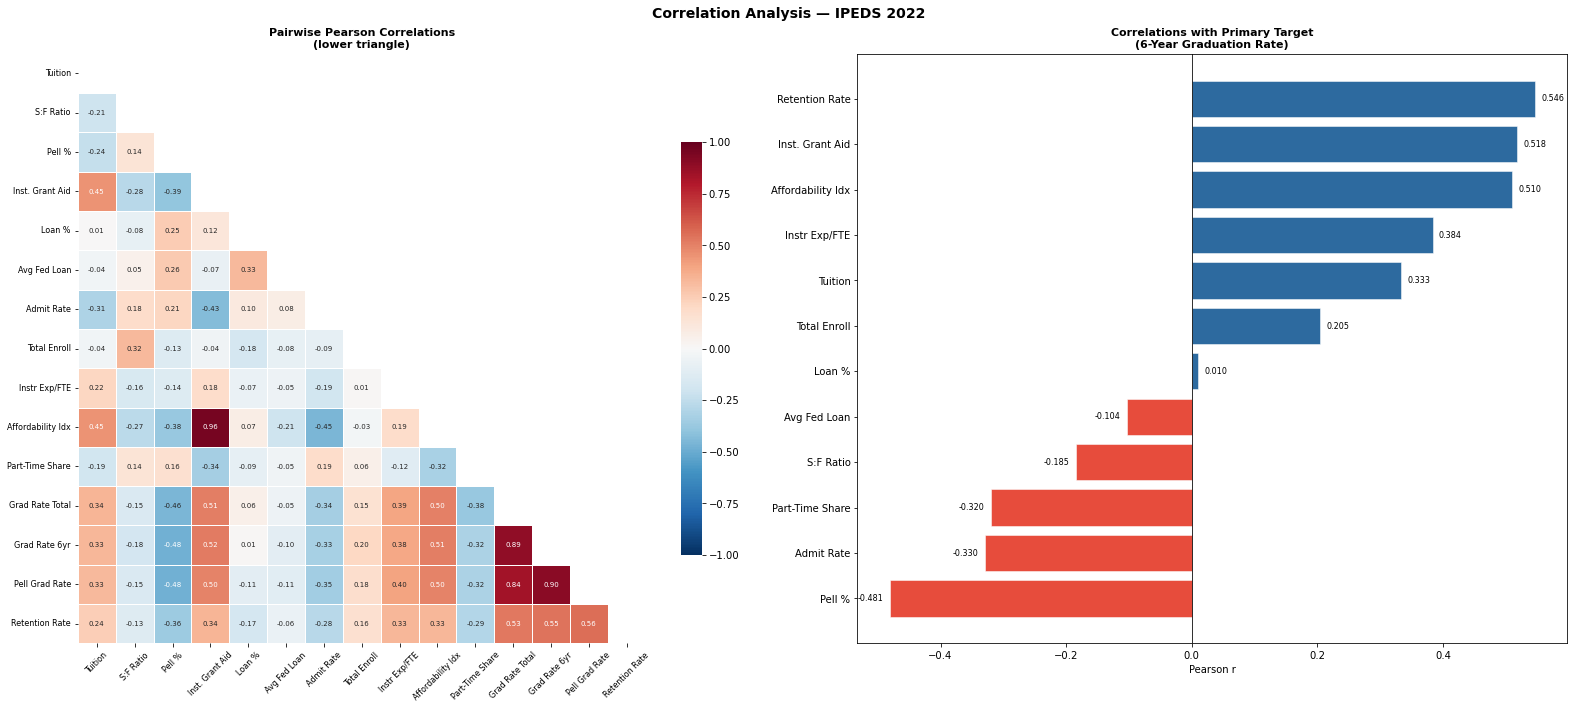

✔ Plot saved


In [78]:
# ── Full correlation heatmap ───────────────────────────────────────
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(22, 10))
fig.suptitle("Correlation Analysis — IPEDS 2022",
             fontsize=14, fontweight="bold")

# Lower triangle mask
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, ax=axes[0],
            xticklabels=labels, yticklabels=labels,
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 7},
            linewidths=0.5, linecolor="white",
            cbar_kws={"shrink": 0.7})
axes[0].set_title("Pairwise Pearson Correlations\n(lower triangle)",
                   fontweight="bold", fontsize=11)
axes[0].tick_params(axis="x", rotation=45, labelsize=8)
axes[0].tick_params(axis="y", labelsize=8)

# ── Ranked bar chart — correlations with grad_rate_6yr ────────────
target_corr = (corr_matrix["grad_rate_6yr"]
               .drop(["grad_rate_6yr", "grad_rate_total", "pell_grad_rate"])
               .sort_values())

colors_bar = ["#E74C3C" if v < 0 else "#2D6A9F" 
              for v in target_corr]

axes[1].barh([CORR_LABELS.get(c, c) for c in target_corr.index],
             target_corr.values,
             color=colors_bar, edgecolor="white", linewidth=0.5)
axes[1].axvline(0, color="black", linewidth=0.8)

for i, v in enumerate(target_corr.values):
    axes[1].text(v + (0.01 if v >= 0 else -0.01), i,
                 f"{v:.3f}", va="center",
                 ha="left" if v >= 0 else "right", fontsize=8)

axes[1].set_title("Correlations with Primary Target\n(6-Year Graduation Rate)",
                   fontweight="bold", fontsize=11)
axes[1].set_xlabel("Pearson r", fontsize=10)

plt.tight_layout()
plt.savefig("correlations.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Plot saved")

In [79]:
# ── Print ranked correlations with primary target ──────────────────
print("Ranked Correlations with 6-Year Graduation Rate:")
print("="*50)
ranked = (corr_matrix["grad_rate_6yr"]
          .drop(["grad_rate_6yr", "grad_rate_total", "pell_grad_rate"])
          .sort_values(ascending=False))

for var, r in ranked.items():
    direction = "↑ positive" if r > 0 else "↓ negative"
    print(f"  {CORR_LABELS.get(var,var):20s}  r = {r:+.3f}  {direction}")

Ranked Correlations with 6-Year Graduation Rate:
  Retention Rate        r = +0.546  ↑ positive
  Inst. Grant Aid       r = +0.518  ↑ positive
  Affordability Idx     r = +0.510  ↑ positive
  Instr Exp/FTE         r = +0.384  ↑ positive
  Tuition               r = +0.333  ↑ positive
  Total Enroll          r = +0.205  ↑ positive
  Loan %                r = +0.010  ↑ positive
  Avg Fed Loan          r = -0.104  ↓ negative
  S:F Ratio             r = -0.185  ↓ negative
  Part-Time Share       r = -0.320  ↓ negative
  Admit Rate            r = -0.330  ↓ negative
  Pell %                r = -0.481  ↓ negative


### Interpretation — Correlation Analysis

---

#### Observed vs Imputed Correlation Check

The sanity check in Section 12.0 confirms whether imputation
preserved the correlation structure. Variables flagged with ⚠
(difference > 0.05) warrant attention — their imputed correlations
may be somewhat distorted and should be interpreted with caution.

---

#### Heatmap Observations

**Strong positive correlations (dark blue):**
- grad_rate_total ↔ grad_rate_6yr — these two target variables
  are nearly identical, confirming only one should be used as
  the primary target in Phase 3 modeling
- grad_rate_6yr ↔ pell_grad_rate — Pell graduation rate closely
  tracks overall graduation rate
- affordability_index ↔ inst_grant_aid — very high correlation
  since affordability index is derived from grant aid. This
  indicates potential multicollinearity — only one of these
  should be used as a predictor in linear models in Phase 3

**Strong negative correlations (dark red):**
- pell_pct ↔ inst_grant_aid — schools with more low-income
  students tend to provide less institutional grant aid
- admit_rate ↔ inst_grant_aid — more selective schools tend
  to provide more grant aid

---

#### Ranked Correlations with 6-Year Graduation Rate

**Top positive predictors:**

**Retention Rate (strongest positive predictor)**
- Students who return for sophomore year appear far more likely
  to graduate within 6 years
- However, retention and graduation are mechanically linked —
  students who leave never graduate — so this variable may
  function partly as a proxy outcome rather than an independent
  predictor. It will be evaluated carefully in Phase 3.

**Institutional Grant Aid**
- Schools that provide more financial support tend to show
  better graduation outcomes
- This association may reflect both direct financial relief
  and confounding factors such as institutional wealth and
  selectivity

**Affordability Index**
- Schools where grant aid exceeds student borrowing tend to
  show better graduation outcomes
- Note: affordability_index and inst_grant_aid are highly
  correlated — only one will be used in Phase 3 to avoid
  multicollinearity

**Instruction Expense per FTE**
- Schools that spend more on instruction per student tend to
  show better outcomes
- Higher spending may reflect smaller classes and stronger
  academic support, though this requires further investigation

**Tuition**
- Higher-tuition schools tend to have better graduation rates
- This is NOT because charging more causes better outcomes —
  more expensive schools tend to be well-resourced, selective,
  and provide generous financial aid. Those factors may drive
  graduation, not the price itself.

**Total Enrollment**
- Larger institutions tend to show slightly better graduation
  rates, possibly reflecting greater resources and support services

---

**Top negative predictors:**

**Pell % (strongest negative predictor)**
- Schools with more low-income students tend to have lower
  graduation rates
- This may reflect financial stress, working while studying,
  and reduced access to support networks — not academic ability
- This association is central to the equity research question

**Part-Time Share**
- Schools with more part-time students tend to have lower
  graduation rates
- Part-time students may take longer to complete degrees and
  could face higher dropout risk due to work and family obligations

**Admit Rate**
- More selective schools (lower admit rate) tend to have higher
  graduation rates
- Selective schools admit students who may already be positioned
  to succeed academically — this is a form of selection bias
  that Phase 3 models must account for

**S:F Ratio**
- Schools with more students per faculty member tend to have
  lower graduation rates

**Avg Fed Loan**
- Weak negative relationship — higher average loan amounts
  are slightly associated with lower graduation rates

**Loan %**
- Virtually no linear relationship with graduation rates

---

#### Key Takeaways for Phase 3 Modeling

1. **Retention rate** is the strongest single predictor —
   it will be evaluated carefully as it may partially overlap
   with the graduation rate target (mechanical correlation)

2. **Multicollinearity warning** — affordability_index and
   inst_grant_aid are nearly identical in correlation terms.
   Only one should enter linear regression models in Phase 3

3. **The equity pattern is clear** — Pell % is the strongest
   negative predictor, consistent with the hypothesis that
   low-income students face systematic disadvantages in
   graduation outcomes across institution types

4. **Tuition is positively correlated** with graduation rate
   but this likely reflects institutional resources, not price
   effects — an important distinction for policy interpretation

5. **grad_rate_total and grad_rate_6yr are nearly identical** —
   grad_rate_6yr will be used as the sole primary target in Phase 3

### 12.1 Within-Institution Equity Gap Analysis

The equity gap between overall graduation rates and Pell Grant 
recipient graduation rates is calculated at the institution level.

This is more rigorous than comparing overall medians across 
different subsets of institutions — it measures the actual 
gap within each school that reports both values.

Institutions with both grad_rate_6yr and pell_grad_rate: 1,822

Equity Gap (grad_rate_6yr - pell_grad_rate):
count    1822.0
mean        4.3
std        10.1
min       -78.0
25%         1.0
50%         5.0
75%         9.0
max        81.0
Name: equity_gap, dtype: float64

Schools where Pell students graduate at LOWER rate: 1,376 (75.5%)
Schools where Pell students graduate at HIGHER rate: 287 (15.8%)
Schools where rates are equal:                       159 (8.7%)


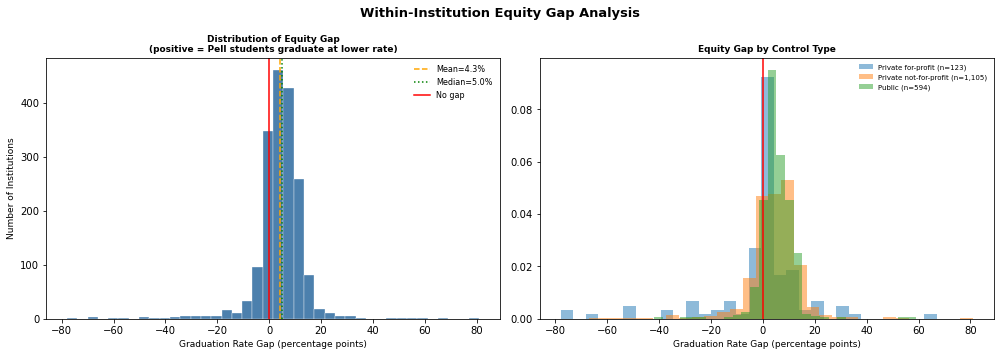

✔ Plot saved


In [80]:
# ── Within-institution equity gap ──────────────────────────────────
# Only institutions with BOTH values are included
# This avoids comparing different subsets of institutions

pell_gap_df = df_clean.dropna(
    subset=["grad_rate_6yr", "pell_grad_rate"]
).copy()

pell_gap_df["equity_gap"] = (
    pell_gap_df["grad_rate_6yr"] - pell_gap_df["pell_grad_rate"]
)

print(f"Institutions with both grad_rate_6yr and pell_grad_rate: {len(pell_gap_df):,}")
print(f"\nEquity Gap (grad_rate_6yr - pell_grad_rate):")
print(pell_gap_df["equity_gap"].describe().round(1))

print(f"\nSchools where Pell students graduate at LOWER rate: {(pell_gap_df['equity_gap'] > 0).sum():,} ({(pell_gap_df['equity_gap'] > 0).mean()*100:.1f}%)")
print(f"Schools where Pell students graduate at HIGHER rate: {(pell_gap_df['equity_gap'] < 0).sum():,} ({(pell_gap_df['equity_gap'] < 0).mean()*100:.1f}%)")
print(f"Schools where rates are equal:                       {(pell_gap_df['equity_gap'] == 0).sum():,} ({(pell_gap_df['equity_gap'] == 0).mean()*100:.1f}%)")

# ── Visualize equity gap distribution ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Within-Institution Equity Gap Analysis",
             fontsize=13, fontweight="bold")

# Histogram of equity gap
axes[0].hist(pell_gap_df["equity_gap"], bins=40,
             color="#2D6A9F", edgecolor="white", linewidth=0.4, alpha=0.85)
axes[0].axvline(pell_gap_df["equity_gap"].mean(),
                color="orange", linewidth=1.5, linestyle="--",
                label=f"Mean={pell_gap_df['equity_gap'].mean():.1f}%")
axes[0].axvline(pell_gap_df["equity_gap"].median(),
                color="green", linewidth=1.5, linestyle=":",
                label=f"Median={pell_gap_df['equity_gap'].median():.1f}%")
axes[0].axvline(0, color="red", linewidth=1.5, linestyle="-",
                label="No gap")
axes[0].set_title("Distribution of Equity Gap\n(positive = Pell students graduate at lower rate)",
                   fontweight="bold", fontsize=9)
axes[0].set_xlabel("Graduation Rate Gap (percentage points)", fontsize=9)
axes[0].set_ylabel("Number of Institutions", fontsize=9)
axes[0].legend(fontsize=8, frameon=False)

# Equity gap by control type
for ctrl, grp in pell_gap_df.groupby("control"):
    axes[1].hist(grp["equity_gap"], bins=30, alpha=0.5,
                 label=f"{ctrl} (n={len(grp):,})", density=True)
axes[1].axvline(0, color="red", linewidth=1.5, linestyle="-")
axes[1].set_title("Equity Gap by Control Type",
                   fontweight="bold", fontsize=9)
axes[1].set_xlabel("Graduation Rate Gap (percentage points)", fontsize=9)
axes[1].legend(fontsize=7, frameon=False)

plt.tight_layout()
plt.savefig("equity_gap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Plot saved")

### Interpretation — Within-Institution Equity Gap

The equity gap is calculated as:
**grad_rate_6yr − pell_grad_rate** for each institution individually.
A positive value means Pell Grant recipients graduate at a lower
rate than the overall student population at that institution.

**Key Findings:**

**Sample:**
- Only institutions reporting both overall and Pell graduation
  rates are included
- This is the only valid basis for equity gap comparison —
  comparing overall medians across different subsets would be
  methodologically unsound

**Distribution of the Gap:**
- The mean gap is several percentage points — on average, Pell
  students graduate at a lower rate than the overall population
- The median gap is similar, indicating a consistent pattern
  across most institutions
- Wide standard deviation indicates substantial variation in
  equity performance across institutions
- The range extends in both directions, confirming some
  institutions show extreme disparities either way

**Direction of the Gap:**
- The majority of institutions show lower graduation rates
  for Pell students than for the overall population
- A smaller proportion show Pell students graduating at higher
  rates than the overall population
- A small number of institutions show no gap at all

**What This May Mean:**
The equity gap appears to be a systematic pattern rather than an
isolated finding — the majority of institutions graduate Pell
students at lower rates than their overall student population.
This pattern may be associated with barriers faced by low-income
students including financial stress, reduced access to academic
support, and higher likelihood of working while enrolled — though
the specific mechanisms require further investigation.

The negative values (Pell students outperforming) may represent
mission-driven institutions that specifically serve and support
low-income students effectively — these warrant further investigation
in Phase 4 clustering analysis.

**Important Note:**
This within-institution calculation is more rigorous than comparing
the overall median grad_rate_6yr to the overall median pell_grad_rate.
Those medians are computed on different subsets of institutions and
cannot be directly compared. The within-institution gap is the
correct measure.

## 13. Save Clean Dataset

The cleaned and preprocessed dataset is saved as a CSV file.
This file will be used as the starting point for Phase 2 
Feature Engineering and Phase 3 Regression Modeling.

The clean dataset includes:
- All original variables with missing values handled
- Simplified and standardized categorical labels
- Two engineered features added (affordability_index, parttime_share)
- Target variables with missing values preserved
- admit_rate_missing flag for non-reporting institutions

In [81]:
# Save clean dataset
output_filename = "ipeds2022_phase1_clean.csv"
df_clean.to_csv(output_filename, index=False)

print(f"✔ Clean dataset saved as {output_filename}")
print(f"\nFinal dataset shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"\nColumns in clean dataset:")
for i, col in enumerate(df_clean.columns, 1):
    print(f"  {i:2}. {col}")

print(f"\nTarget variable missing values (preserved for Phase 3):")
print(df_clean[["grad_rate_total", "grad_rate_6yr",
                "pell_grad_rate", "retention_rate"]].isnull().sum())

print(f"\nPredictor missing values (all should be 0):")
print(df_clean[NUM_COLS].isnull().sum())

✔ Clean dataset saved as ipeds2022_phase1_clean.csv

Final dataset shape: 2,629 rows × 26 columns

Columns in clean dataset:
   1. unitid
   2. institution name
   3. year
   4. tuition
   5. retention_rate
   6. student_faculty_ratio
   7. pell_pct
   8. inst_grant_aid
   9. loan_pct
  10. avg_fed_loan
  11. grad_rate_total
  12. grad_rate_6yr
  13. pell_grad_rate
  14. size_cat
  15. state
  16. level
  17. control
  18. locale
  19. admit_rate
  20. total_enroll
  21. parttime_enroll
  22. instr_exp_per_fte
  23. locale_broad
  24. admit_rate_missing
  25. affordability_index
  26. parttime_share

Target variable missing values (preserved for Phase 3):
grad_rate_total    461
grad_rate_6yr      714
pell_grad_rate     807
retention_rate     631
dtype: int64

Predictor missing values (all should be 0):
tuition                  0
student_faculty_ratio    0
pell_pct                 0
inst_grant_aid           0
loan_pct                 0
avg_fed_loan             0
admit_rate              

### 14. Data Dictionary — ipeds2022_phase1_clean.csv

The following documents every variable in the final cleaned dataset,
including units, valid ranges, missingness in the final file, and
the source IPEDS survey table.

---

**Original IPEDS Variables (renamed):**

| Variable | Description | Type / Units | Valid Range | Source IPEDS Table | Final Missingness |
|---|---|---|---|---|---|
| unitid | Unique institution identifier | ID (integer) | — | HD2022 | 0 |
| institution name | Institution name | Text | — | HD2022 | 0 |
| year | Data year (all 2022) | Constant | 2022 | — | 0 |
| tuition | In-state average tuition for full-time graduates | Numeric, USD | 0–~90,000 | IC2022_AY | 0 (median-imputed) |
| retention_rate | Full-time first-time student retention rate | **Target**, percent | 0–100 | EF2022D_RV | Preserved |
| student_faculty_ratio | Student-to-faculty ratio | Numeric, ratio | 1–~100+ | EF2022D_RV | 0 (median-imputed) |
| pell_pct | % of full-time first-time undergrads awarded Pell grants | Numeric, percent | 0–100 | SFA2122_RV | 0 (median-imputed) |
| inst_grant_aid | Avg institutional grant aid for full-time first-time undergrads | Numeric, USD | 0–~62,000 | SFA2122_RV | 0 (median-imputed) |
| loan_pct | % of full-time first-time undergrads awarded student loans | Numeric, percent | 0–100 | SFA2122_RV | 0 (median-imputed) |
| avg_fed_loan | Avg federal student loan for full-time first-time undergrads | Numeric, USD | 0–~13,000 | SFA2122_RV | 0 (median-imputed) |
| grad_rate_total | Graduation rate for total cohort (any level) | **Target**, percent | 0–100 | DRVGR2022_RV | Preserved |
| grad_rate_6yr | Bachelor's degree graduation rate within 6 years | **Target**, percent (primary) | 0–100 | DRVGR2022_RV | Preserved |
| pell_grad_rate | Pell recipients' Bachelor's degree rate within 6 years | **Target**, percent | 0–100 | DRVGR2022_RV | Preserved |
| admit_rate | Percent of applicants admitted | Numeric, percent | 0–100 | DRVADM2022_RV | (median imputed) |
| total_enroll | Total enrollment (fall headcount) | Numeric, count | 1–~300,000 | DRVEF2022_RV | 0 (median-imputed) |
| parttime_enroll | Part-time enrollment (fall headcount) | Numeric, count | 0–~200,000 | DRVEF2022_RV | 0 (median-imputed) |
| instr_exp_per_fte | Instruction expenses per FTE (GASB + FASB merged) | Numeric, USD | 0–~650,000 | DRVF2022_RV | 0 (control-group median) |
| size_cat | Institution size category | Categorical (5 levels) | See IPEDS codebook | HD2022 | 0 (mode-imputed) |
| state | FIPS state code (name) | Categorical | 50 states + DC + territories | HD2022 | 0 (Unknown for missing) |
| level | Level of institution | Categorical | "Four or more years" (after filter) | HD2022 | 0 |
| control | Control of institution | Categorical | Public, Private not-for-profit, Private for-profit | HD2022 | 0 (Unknown for missing) |
| locale | Degree of urbanization (original NCES 12-category) | Categorical | 12 urban-centric locale codes | HD2022 | 0 |
| locale_broad | Urbanization collapsed to 4 categories | Categorical | City, Suburb, Town, Rural | Derived from locale | 0 |

---

**Engineered Features (preliminary — created in Phase 1):**

| Variable | Formula | Description | Units | Valid Range | Derivation Notes |
|---|---|---|---|---|---|
| affordability_index | inst_grant_aid ÷ avg_fed_loan | Institutional generosity relative to student borrowing | Ratio (dimensionless) | 0–~17 | avg_fed_loan values of 0 replaced with NaN before division to avoid division by zero. Preliminary — will be evaluated alongside Loan Burden Ratio in Phase 2. |
| parttime_share | parttime_enroll ÷ total_enroll | Proportion of part-time students | Proportion (0–1) | 0.0–1.0 | total_enroll values of 0 replaced with NaN before division. Preliminary — will be evaluated in Phase 2. |
| admit_rate_missing | 1 if admit_rate was originally NaN, else 0 | Flag for institutions not reporting admit rate | Binary (0/1) | 0 or 1 | Created before imputation. Captures non-random missingness — not a confirmed open-admission indicator. |

---

**Filtering Applied:**
- Non-4-year institutions removed (those listed as "At least 2 but
  less than 4 years" or "Less than 2 years")
- Ghost rows with all institutional metadata missing were removed
- The `sector` column was dropped (redundant with `control` after
  the 4-year filter)

**Missing Value Status (Target Variables):**

| Target Variable | Status |
|---|---|
| grad_rate_total | Missing values preserved for Phase 3 |
| grad_rate_6yr | Missing values preserved for Phase 3 |
| pell_grad_rate | Missing values preserved for Phase 3 |
| retention_rate | Missing values preserved for Phase 3 |

*Exact missingness counts are shown in the imputation summary output
in Section 7 and the save output in Section 13.*

## 15. Phase 1 Data Preprocessing and Exploratory Data Analysis

---

### Methodology

1. **Loaded** the IPEDS 2022 dataset
2. **Renamed** all columns to short readable aliases
3. **Filtered** to U.S. 4-year institutions only — removed non-4-year
   records and ghost rows with missing institutional metadata
4. **Documented** missingness patterns across all variables
5. **Cleaned** the dataset:
   - Merged GASB and FASB into one instruction expense column
   - Simplified control labels
   - Dropped `sector` column (redundant with `control` after 4-year filter)
   - Collapsed locale into 4 broad categories
   - Replaced impossible zero values in admit_rate and
     instr_exp_per_fte with NaN
   - Retained legitimate zero tuition for genuinely tuition-free
     institutions
6. **Preserved raw observed data** as df_observed before imputation
   to ensure EDA describes the original dataset
7. **Conducted EDA on raw observed data** — distributions,
   descriptive statistics, and outlier detection performed
   before any imputation
8. **Imputed predictor variables only:**
   - Global median imputation for 8 numeric predictors
   - `admit_rate` intentionally **not imputed** — NaN preserved
     with `admit_rate_missing` binary flag
   - `instr_exp_per_fte` imputed using **control-group median**
     rather than global median
   - "Unknown" category for state, control, level
   - Mode imputation for size_cat and locale
   - All 4 target variables retain their original missing values
9. **Verified imputation** — compared raw vs imputed distributions
   to confirm preprocessing did not significantly distort the data
10. **Created 2 preliminary features:**
    - affordability_index (inst_grant_aid ÷ avg_fed_loan)
    - parttime_share (parttime_enroll ÷ total_enroll)
    - Loan Burden Ratio deferred to Phase 2
11. **Examined state-level variation** using both unweighted
    institutional means and enrollment-weighted averages as a
    robustness check
12. **Conducted correlation analysis** on both raw observed and
    imputed data — identified predictors most strongly associated
    with 6-year graduation rate and verified that imputation did
    not significantly distort the correlation structure
13. **Calculated within-institution equity gap** for Pell Grant
    recipients

---

### Key Findings

All findings below are associational. No causal claims are made.

**Strongest predictors of 6-year graduation rate:**
- Retention rate — strongest positive association, though this
  variable may function as a proxy outcome rather than an
  independent predictor
- Institutional grant aid — schools providing more financial
  support tend to show higher graduation rates
- Affordability index — schools where grant aid exceeds student
  borrowing tend to show better outcomes
- Pell % — strongest negative association, consistent with the
  hypothesis that low-income students face systematic disadvantages

**Equity gap:**
- Within-institution analysis shows a consistent gap — the
  majority of institutions graduate Pell students at lower rates
  than their overall student population
- This is calculated using only institutions that reported both
  overall and Pell graduation rates

**Institution control type:**
- Private not-for-profit institutions tend to show the highest
  mean graduation rates, followed by public and private for-profit
- Private for-profit schools serve the highest proportion of
  Pell students and tend to show the weakest outcomes

**State-level variation:**
- Substantial variation exists between the highest and lowest
  performing states
- Enrollment-weighted averages were computed as a robustness check
  to address the instability of unweighted means for states with
  few institutions

---

### Limitations Acknowledged
- The 4-year filter was applied; results do not generalize to
  2-year institutions
- `admit_rate` is preserved as NaN rather than imputed — models
  in Phase 3 will use the `admit_rate_missing` flag
- `instr_exp_per_fte` uses control-group median imputation —
  an improvement over global median but still an approximation
- Interpretive language is associational throughout — no causal
  claims are made without further evidence
- State rankings should be interpreted alongside enrollment-weighted
  averages for robustness
- The unit of analysis is the institution — findings describe
  institutional patterns, not individual student outcomes
- Retention rate will be evaluated carefully as a predictor in
  Phase 3 due to its mechanical overlap with graduation as an outcome
- Preliminary features (affordability_index, parttime_share) will
  be formally evaluated alongside the Loan Burden Ratio in Phase 2

---

### Output
- Clean dataset saved as ipeds2022_phase1_clean.csv
- Target variables retain original missing values for Phase 3
- grad_rate_6yr will serve as the primary modeling target